In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import GridSpec
import matplotlib.gridspec as gridspec
import glob
import pandas as pd
import math
from math import sqrt
import random
import scipy
from scipy.stats import mannwhitneyu

import seaborn as sns

plt.style.use('styleNB.mplstyle')

wt = 'dHL60KW'
ko = 'dHL60TMEM154KO'
res = 'dHL60TMEM154KO-clone1galvanin-GFP-HA'


# Figure 2 Related

## Load in data

In [2]:
f_compiled = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_tracking.csv'

df = pd.read_csv(f_compiled)
df = df[['cell', 'frame', 'x', 'y', 'z', 'celltype', 'E_V_cm',
       'date', 'trial', 'user']]
df = df[df.celltype != 'dHL60TMEM154KO-clone1galvanin-GFP-HA']

f_rescue_filtered = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_rescue_tracking_GFPplus.csv'
df_gfp = pd.read_csv(f_rescue_filtered)
df_gfp = df_gfp[['cell', 'frame', 'x', 'y', 'z',
       'celltype', 'E_V_cm', 'date', 'trial', 'user']]


df = pd.concat([df, df_gfp], ignore_index = True)

df = df.replace('dHL60TMEM154KO-clone1', 'dHL60TMEM154KO')
df = df.replace('dHL60TMEM154KO-clone12', 'dHL60TMEM154KO')

#  Step 1: Remove cells at the periphery
df_temp_ = pd.DataFrame()
for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df = df_temp_

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20: #14:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0], row.z.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks (still only 2D for this filter)
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1],
            'z': positions[:, 2]
        })
    ], ignore_index=True)


# Step 3: subsample every three minutes
def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out

df.celltype.unique()

array(['dHL60KW', 'dHL60TMEM154KO',
       'dHL60TMEM154KO-clone1galvanin-GFP-HA'], dtype=object)

In [3]:
celllines = df.celltype.unique() 
colors = sns.color_palette("tab10")
color_dict = dict(zip(df.celltype.unique(), colors))    
color_dict.update({'dHL60KW':'#B8BABC'})
# df.celltype.unique() = array(['dHL60KW', 'dHL60TMEM154KO',
       # 'dHL60TMEM154KO-clone1galvanin-GFP-HA'], dtype=object)

In [4]:
# df_filtered_tracks.head()

color_dict



{'dHL60KW': '#B8BABC',
 'dHL60TMEM154KO': (1.0, 0.4980392156862745, 0.054901960784313725),
 'dHL60TMEM154KO-clone1galvanin-GFP-HA': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313)}

# Autocorrelation analysis and plots

In [7]:
###############################
# Autocorrelation calculation
###############################

# def non_overlapping_normalized_autocorrelation(signal):
#     """
#     Calculate the non-overlapping normalized autocorrelation of a 1D signal.
    
#     Parameters:
#     signal (np.ndarray): Input 1D signal.
    
#     Returns:
#     np.ndarray: Non-overlapping normalized autocorrelation values.
#     """
#     n = len(signal)
#     autocorrelation = np.zeros(n)
    
#     for lag in range(n):
#         sum_product = 0
#         count = 0
#         for i in range(0, n - lag, lag + 1):
#             sum_product += signal[i] * signal[i + lag]
#             count += 1
        
#         if count > 0:
#             # Normalizing with respect to the sum of squares for lag 0
#             normalization_factor = np.sqrt(np.sum(signal[:n - lag:lag + 1] ** 2) * np.sum(signal[lag:n:lag + 1] ** 2))
#             autocorrelation[lag] = sum_product / normalization_factor if normalization_factor != 0 else 0
    
#     return autocorrelation
    

# def non_overlapping_normalized_autocorrelation(signal):
#     """
#     Compute the non-overlapping, normalized autocorrelation of a 1D signal.

#     Parameters:
#     signal (np.ndarray): Input 1D signal.

#     Returns:
#     np.ndarray: Autocorrelation values at non-overlapping lags.
#     """
#     signal = np.asarray(signal)
#     n = len(signal)
#     max_lag = n // 2  # limit lags to avoid very short segments
#     autocorr = np.zeros(max_lag)

#     for lag in range(max_lag):
#         s1 = signal[:n - lag:lag + 1]
#         s2 = signal[lag:n:lag + 1]

#         if len(s1) != len(s2):
#             min_len = min(len(s1), len(s2))
#             s1 = s1[:min_len]
#             s2 = s2[:min_len]

#         if len(s1) > 0:
#             numerator = np.sum(s1 * s2)
#             denominator = np.sqrt(np.sum(s1**2) * np.sum(s2**2))
#             autocorr[lag] = numerator / denominator if denominator != 0 else 0

#     return autocorr
    


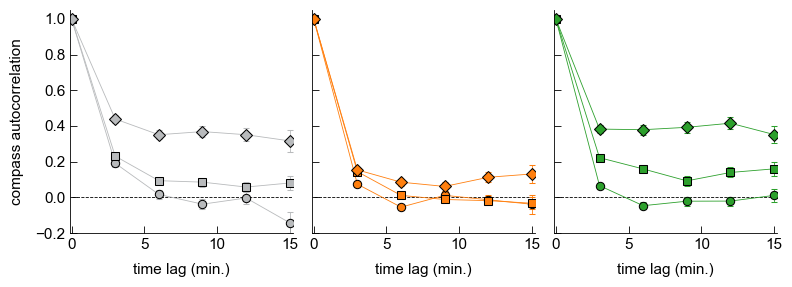

In [7]:
# df_intervals_3 = parse_trajectories(df_filtered_tracks, frame_step=3)

# autocorr_list = []

# for g, d in df_intervals_3[df_intervals_3.E_V_cm != 5].groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
#     d_sorted = d.sort_values('interval')
#     vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
#     angles = np.arctan2(vectors[:,1], vectors[:,0])
#     cos_angles = np.cos(angles)

#     acf = non_overlapping_normalized_autocorrelation(cos_angles)

#     autocorr_list.append(pd.DataFrame({
#         'celltype': g[0],
#         'E_V_cm': g[1],
#         'lag': np.arange(len(acf)) * 3,  # actual lag in frames
#         'autocorr': acf
#     }))
    
# df_autocorr = pd.concat(autocorr_list, ignore_index=True)

# df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
#     mean_autocorr=('autocorr', 'mean'),
#     sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
#     num_trajectories=('autocorr', 'count')
# ).reset_index()


# celltypes = df_avg_autocorr.celltype.unique()
# fig, axes = plt.subplots(1, len(celltypes), figsize = (8,3), sharey=True)# figsize=(3*len(celltypes),3), sharey=True)

# if len(celltypes) == 1:
#     axes = [axes]

# for ax, celltype in zip(axes, celltypes):
#     data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]
#     for e, d in data.groupby('E_V_cm'):
#         num_traj = d.num_trajectories.values[0]  # same across lags if consistent
#         ax.errorbar(
#             d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
#             label=f"{e} V/cm (n={num_traj})", capsize=2, marker='o', markersize = 4
#         )
#     ax.set_title(celltype, fontsize=12)

# for ax_ in axes:
#     ax_.set_xlim(-0.1, 5*3+0.2)
#     ax_.set_ylim(-0.2, 1.05)
#     ax_.hlines(0,0,6*3, zorder = 0, color = 'k', linestyle = '--')
#     ax_.set_xlabel('time lag (min.)')

# axes[0].set_ylabel('compass autocorrelation')


# plt.tight_layout()
# plt.savefig('../../figures/Figure3_supp_autocorr_updated_.pdf')

def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr



marker_dict = {
    0: 'o',
    1: 's',
    3: 'D'
    # Add more if needed
}

df_intervals_3 = parse_trajectories(df_filtered_tracks, frame_step=3)

autocorr_list = []

for g, d in df_intervals_3[df_intervals_3.E_V_cm != 5].groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 3,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()

celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(8, 3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype == celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})",
            capsize=2,
            marker=marker_dict.get(e, 'o'),  # default to 'o' if unknown
            markersize=6,
            color=color_dict.get(celltype, 'gray'),  # default to gray if unknown
             markeredgecolor='k',       # black outline
            markeredgewidth=0.75       # adjust thickness as needed
        )
    # ax.set_title(celltype, fontsize=12)

for ax_ in axes:
    ax_.set_xlim(-0.1, 5*3 + 0.2)
    ax_.set_ylim(-0.2, 1.05)
    ax_.hlines(0, 0, 6*3, zorder=0, color='k', linestyle='--')
    ax_.set_xlabel('time lag (min.)')
    ax_.grid(False)

axes[0].set_ylabel('compass autocorrelation')

plt.tight_layout()
# plt.savefig('../../figures/Figure3_supp_autocorr_updated_.pdf')

In [8]:
for g, d in df_angle_E_3.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user']):
    if g[0] != 'dHL60TMEM154KO-clone1galvanin-GFP-HA': #'dHL60KW':
        continue
    if g[1] == 5:
        continue
    print(g)
    print(len(d.cell.unique()))

NameError: name 'df_angle_E_3' is not defined

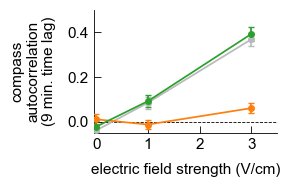

In [150]:
# Choose lag of interest (in minutes)
lag_of_interest = 9  # e.g., for 6 min
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Group by condition
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(3, 2))

for celltype, d in df_lag_stats.groupby('celltype'):
    ax.errorbar(
        d['E_V_cm'], d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1.25, marker='o', markersize=4,
        color=color_dict.get(celltype, None),  # fallback if not in dict
        zorder=10, capsize=2
    )

ax.hlines(0, 0, df_lag_stats['E_V_cm'].max() + 0.5, color='k', linestyle='--', zorder=0)

ax.set_xlim(-0.05, 3.5)
ax.set_ylim(-0.05, 0.5)

ax.set_xlabel('electric field strength (V/cm)')
ax.set_ylabel(f'compass\nautocorrelation\n({lag_of_interest} min. time lag)')

# # Move legend outside
# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
# plt.savefig('../../figures/Figure3_autocorrelation_updated.pdf')


# Histogram plots of speed along electric field direction

0 V/cm — WT: 614 | KO: 1026 | Rescue: 769
3 V/cm — WT: 538 | KO: 976 | Rescue: 449


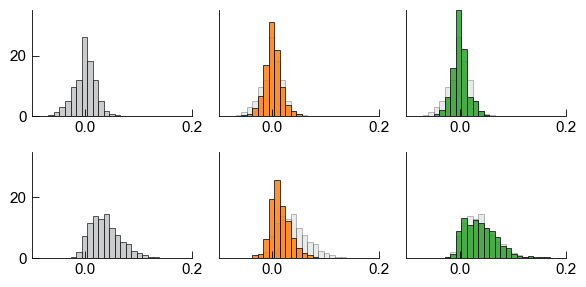

In [11]:
# # I want plots with equally spaced bins across all the cell lines. I need to determine the data range first.; otherwise this can be ignored.

# count = 0
# for E, df_temp in df.groupby('E_V_cm'):
#     # if E == 5:
#     #     continue
#     if E == 1:
#         continue
        
#     count_int_kw = 0
#     count_cell_kw = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60KW'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         dot_kw = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             if len(d_.frame.unique()) > 10:
#                 tot = 0
#                 for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                     vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                               d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                     tot += vec_t1[0]
#                     count_int_kw += 1
                    
#                 dot_kw = np.append(dot_kw,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))
                
#             count_cell_kw += 1
    
#     count_int_ko = 0
#     count_cell_ko = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60TMEM154KO'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         dot_ko = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             if len(d_.frame.unique()) > 10:
#                 tot = 0
#                 for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                     vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                               d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                     tot += vec_t1[0]
#                     count_int_ko += 1
                    
#                 dot_ko = np.append(dot_ko,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))
                
#             count_cell_ko += 1
            
#     count_int_res = 0
#     count_cell_res = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         dot_res = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             if len(d_.frame.unique()) > 10:
#                 tot = 0
#                 for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                     vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                               d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                     tot += vec_t1[0]
#                     count_int_res += 1
                    
#                 dot_res = np.append(dot_res,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))

#             count_cell_res += 1

    
#     count += 1


displacement_records = []

for (celltype, E), group in df_intervals_3[df_intervals_3.E_V_cm != 1].groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        if len(dx) == 0:
            continue
        mean_dx = np.mean(dx)
        displacement_records.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_dx': mean_dx
        })

df_displacement = pd.DataFrame(displacement_records)


fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(6, 3))
axs = axs.ravel()

bins = np.linspace(-0.1, 0.2, 30)
wt = 'dHL60KW'
ko = 'dHL60TMEM154KO'
res = 'dHL60TMEM154KO-clone1galvanin-GFP-HA'

# Group once to avoid recomputing
wt_data = df_displacement[df_displacement.celltype == wt]
wt_histograms = {}

for E in sorted(df_displacement.E_V_cm.unique()):
    if E in [1, 5]:
        continue

    # Extract WT values for current E
    wt_vals = wt_data[wt_data.E_V_cm == E]['mean_dx'].values / (3.0 * 60.0)
    wt_histograms[E] = wt_vals  # store for reuse

# Plot loop
for plot_index, E in enumerate(sorted(df_displacement.E_V_cm.unique())):
    if E in [1, 5]:
        continue

    # Column indices
    col_wt, col_ko, col_res = plot_index * 3, plot_index * 3 + 1, plot_index * 3 + 2
    ax_wt, ax_ko, ax_res = axs[col_wt], axs[col_ko], axs[col_res]

    # Wild-type full plot (left column)
    ax_wt.hist(wt_histograms[E], bins=bins, density=True,
               alpha=0.75, linewidth=0.6, edgecolor='black',
               color=color_dict[wt], label='wild-type')

    # WT overlay on KO + rescue (semi-transparent)
    for ax in [ax_ko, ax_res]:
        ax.hist(wt_histograms[E], bins=bins, density=True,
                alpha=0.3, linewidth=0.6, edgecolor='black',
                color=color_dict[wt], label='wild-type (ref)')

    # KO histogram
    ko_vals = df_displacement[
        (df_displacement.celltype == ko) & (df_displacement.E_V_cm == E)
    ]['mean_dx'].values / (3.0 * 60.0)
    ax_ko.hist(ko_vals, bins=bins, density=True,
               alpha=0.85, linewidth=0.6, edgecolor='black',
               color=color_dict[ko], label='KO')

    # Rescue histogram
    res_vals = df_displacement[
        (df_displacement.celltype == res) & (df_displacement.E_V_cm == E)
    ]['mean_dx'].values / (3.0 * 60.0)
    ax_res.hist(res_vals, bins=bins, density=True,
                alpha=0.85, linewidth=0.6, edgecolor='black',
                color=color_dict[res], label='Rescue')

    # Debug print
    print(f"{E} V/cm — WT: {len(wt_histograms[E])} | KO: {len(ko_vals)} | Rescue: {len(res_vals)}")

# Axes formatting
for i, ax in enumerate(axs):
    ax.set_xlim(-0.1, 0.2)
    ax.set_ylim(0, 35)
    ax.set_yticks([0, 20])
    if i % 3 != 0:
        ax.yaxis.set_visible(False)

plt.tight_layout()
# plt.savefig('../../figures/Figure3_projected_speeds_updated.pdf')


E = 0 V/cm
dHL60KW vs dHL60TMEM154KO: Mann–Whitney U p = 0.3152 (n_WT=4, n_KO=7)
dHL60KW vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.3301 (n_WT=4, n_Rescue=9)
dHL60TMEM154KO vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 1 (n_KO=7, n_Rescue=9)

E = 1 V/cm
dHL60KW vs dHL60TMEM154KO: Mann–Whitney U p = 0.001332 (n_WT=6, n_KO=8)
dHL60KW vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.4452 (n_WT=6, n_Rescue=7)
dHL60TMEM154KO vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.0003108 (n_KO=8, n_Rescue=7)

E = 3 V/cm
dHL60KW vs dHL60TMEM154KO: Mann–Whitney U p = 0.006061 (n_WT=4, n_KO=7)
dHL60KW vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.6095 (n_WT=4, n_Rescue=6)
dHL60TMEM154KO vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.03497 (n_KO=7, n_Rescue=6)


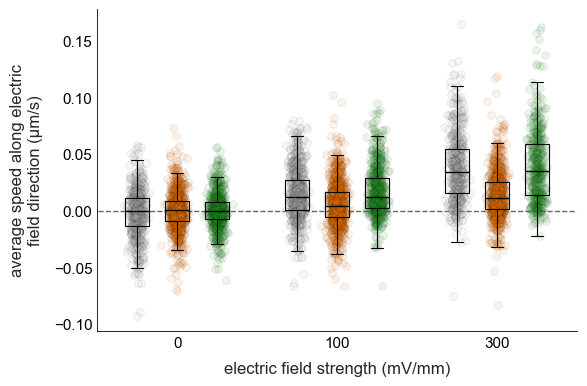

In [93]:


# # Normalize to speed in μm/s
# df_displacement['mean_speed'] = df_displacement['mean_dx'] / (3.0 * 60.0)

# # Filter to E field strengths of interest
# df_plot = df_displacement[df_displacement.E_V_cm.isin([0, 1, 3])]

# # Celltype order and color
# celltypes = [wt, ko, res]
# celltype_labels = ['WT', 'KO', 'Rescue']
# color_palette = [color_dict[wt], color_dict[ko], color_dict[res]]
# celltype_color_dict = dict(zip(celltypes, color_palette))

# # Set plot style
# sns.set(style="whitegrid")
# fig, ax = plt.subplots(figsize=(8, 5))

# # Strip plot
# sns.stripplot(
#     data=df_plot,
#     x='E_V_cm',
#     y='mean_speed',
#     hue='celltype',
#     hue_order=celltypes,
#     dodge=True,
#     palette=celltype_color_dict,
#     jitter=0.15,
#     size=5,
#     linewidth=0.5,
#     edgecolor='black',
#     alpha=0.1,
#     ax=ax
# )

# # Add median lines
# width = 0.05  # Half-width of horizontal line
# for i, celltype in enumerate(celltypes):
#     for j, E in enumerate([0, 1, 3]):
#         data_subset = df_plot[(df_plot['celltype'] == celltype) & (df_plot['E_V_cm'] == E)]
#         if len(data_subset) == 0:
#             continue
#         median_val = data_subset['mean_speed'].median()

#         # x-position logic matches seaborn's dodge behavior
#         x_pos = j - 0.25 + i * 0.25  # tweak if dodge size changes
#         ax.hlines(y=median_val, xmin=x_pos - width, xmax=x_pos + width, color='black', linewidth=1.5, zorder=5)

displacement_records = []

for (celltype, E), group in df_intervals_3.groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        if len(dx) == 0:
            continue
        mean_dx = np.mean(dx)
        displacement_records.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_dx': mean_dx
        })

df_displacement_proj = pd.DataFrame(displacement_records)

# Normalize speed
df_displacement_proj['mean_speed'] = df_displacement_proj['mean_dx'] / (3.0 * 60.0)
df_plot = df_displacement_proj[df_displacement_proj.E_V_cm.isin([0, 1, 3])]

####################################################
####################################################
# Group and aggregate mean speed per (date, trial, user, E, celltype)
agg = (
    df_displacement
    .groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'])['mean_speed']
    .mean()
    .reset_index()
)

# Pivot so each group becomes a row with WT, KO, Rescue columns
pivoted = (
    agg.pivot_table(index=['date', 'trial', 'user', 'E_V_cm'],
                    columns='celltype',
                    values='mean_speed')
    .reset_index()
)

for E in [0, 1, 3]:
    sub = pivoted[pivoted['E_V_cm'] == E]
    print(f"\nE = {E} V/cm")

    if all(ct in sub.columns for ct in [wt, ko]):
        wt_vals = sub[wt].dropna()
        ko_vals = sub[ko].dropna()
        if len(wt_vals) > 0 and len(ko_vals) > 0:
            stat, p = mannwhitneyu(wt_vals, ko_vals, alternative='two-sided')
            print(f"{wt} vs {ko}: Mann–Whitney U p = {p:.4g} (n_WT={len(wt_vals)}, n_KO={len(ko_vals)})")

    if all(ct in sub.columns for ct in [wt, res]):
        wt_vals = sub[wt].dropna()
        res_vals = sub[res].dropna()
        if len(wt_vals) > 0 and len(res_vals) > 0:
            stat, p = mannwhitneyu(wt_vals, res_vals, alternative='two-sided')
            print(f"{wt} vs {res}: Mann–Whitney U p = {p:.4g} (n_WT={len(wt_vals)}, n_Rescue={len(res_vals)})")

    if all(ct in sub.columns for ct in [ko, res]):
        ko_vals = sub[ko].dropna()
        res_vals = sub[res].dropna()
        if len(ko_vals) > 0 and len(res_vals) > 0:
            stat, p = mannwhitneyu(ko_vals, res_vals, alternative='two-sided')
            print(f"{ko} vs {res}: Mann–Whitney U p = {p:.4g} (n_KO={len(ko_vals)}, n_Rescue={len(res_vals)})")

####################################################
####################################################

# Order and color
celltypes = [wt, ko, res]
colors = [color_dict[wt], color_dict[ko], color_dict[res]]
celltype_color_dict = dict(zip(celltypes, colors))
E_levels = [0, 1, 3]

# Plot setup
fig, ax = plt.subplots(figsize=(6, 4))
group_spacing = 1.0
dodge_offset = 0.25  # spacing within group
jitter_scale = 0.025
box_width = 0.15

legend_entries = {}

for i, E in enumerate(E_levels):
    x_base = i * group_spacing
    for j, celltype in enumerate(celltypes):
        x_pos = x_base + (j - 1) * dodge_offset
        df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
        speeds = df_subset['mean_speed'].values

        if len(speeds) == 0:
            continue

        # Matplotlib boxplot at specific x
        bp = ax.boxplot(
            [speeds],
            positions=[x_pos],
            widths=box_width,
            patch_artist=True,
            showcaps=True,
            showfliers=False,
            boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
            medianprops=dict(color='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=0.8),
            capprops=dict(color='black', linewidth=0.8),
        )

        # Jittered scatter points
        jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
        scatter = ax.scatter(
            jittered_x,
            speeds,
            s=30,
            color=celltype_color_dict[celltype],
            alpha=0.1,
            edgecolor='black',
            linewidth=0.5,
            label=celltype if (E == 0) and (celltype not in legend_entries) else None
        )
        legend_entries[celltype] = scatter

# Formatting
xticks = [i * group_spacing for i in range(len(E_levels))]
xticklabels = [str(e*100) for e in E_levels]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel("electric field strength (mV/mm)", fontsize=12)
ax.set_ylabel("average speed along electric\nfield direction (μm/s)", fontsize=12)
ax.grid(False)
ax.hlines(y=0, xmin=-1, xmax=3 + width, color='black', linestyle = '--', linewidth=1, zorder=0, alpha = 0.6)

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
# ax.legend(unique.values(), unique.keys(), title='Cell Type', fontsize=9, title_fontsize=10)


ax.set_xlim(-0.5, 2.5)
# ax.legend(title='Cell Type', title_fontsize=10, fontsize=9)

        # Make axes (spines and ticks) black
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(0.6)

# Optional: hide top/right spines if not needed
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set tick colors and widths
ax.tick_params(axis='both', colors='black', width=0.6, length=5)

plt.tight_layout()



E = 0 V/cm
dHL60KW vs dHL60TMEM154KO: Mann–Whitney U p = 0.3152 (n_WT=4, n_KO=7)
dHL60KW vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.2601 (n_WT=4, n_Rescue=9)
dHL60TMEM154KO vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.6806 (n_KO=7, n_Rescue=9)

E = 1 V/cm
dHL60KW vs dHL60TMEM154KO: Mann–Whitney U p = 0.5728 (n_WT=6, n_KO=8)
dHL60KW vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.366 (n_WT=6, n_Rescue=7)
dHL60TMEM154KO vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.152 (n_KO=8, n_Rescue=7)

E = 3 V/cm
dHL60KW vs dHL60TMEM154KO: Mann–Whitney U p = 0.2303 (n_WT=4, n_KO=7)
dHL60KW vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.1143 (n_WT=4, n_Rescue=6)
dHL60TMEM154KO vs dHL60TMEM154KO-clone1galvanin-GFP-HA: Mann–Whitney U p = 0.4452 (n_KO=7, n_Rescue=6)


NameError: name 'width' is not defined

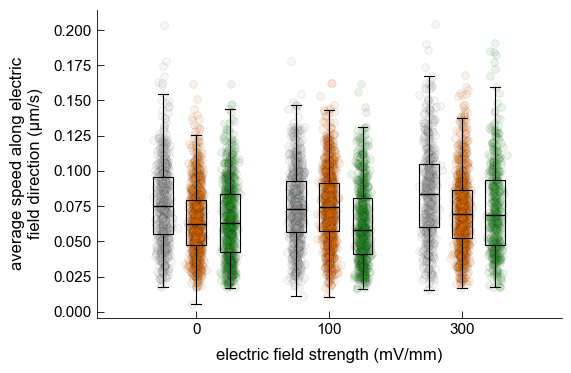

In [10]:


displacement_records_mag = []

# Assume z column exists in df_intervals_3
for (celltype, E), group in df_intervals_3[df_intervals_3.E_V_cm.isin([0, 1, 3])].groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        dy = np.diff(d['y'].values)
        dz = np.diff(d['z'].values)
        if len(dx) == 0:
            continue
        speeds = [sqrt(dx[i]**2 + dy[i]**2 + dz[i]**2) for i in range(len(dx))]
        mean_speed = np.mean(speeds)
        displacement_records_mag.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_speed': mean_speed / (3.0 * 60.0)  # Normalize for 3-frame interval (in μm/s)
        })

df_displacement_mag = pd.DataFrame(displacement_records_mag)
df_plot = df_displacement_mag.copy()

E_levels = [0, 1, 3]
celltypes = [wt, ko, res]

####################################################
####################################################
# Group and aggregate mean speed per (date, trial, user, E, celltype)
agg = (
    df_displacement_mag
    .groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'])['mean_speed']
    .mean()
    .reset_index()
)

# Pivot so each group becomes a row with WT, KO, Rescue columns
pivoted = (
    agg.pivot_table(index=['date', 'trial', 'user', 'E_V_cm'],
                    columns='celltype',
                    values='mean_speed')
    .reset_index()
)

for E in [0, 1, 3]:
    sub = pivoted[pivoted['E_V_cm'] == E]
    print(f"\nE = {E} V/cm")

    if all(ct in sub.columns for ct in [wt, ko]):
        wt_vals = sub[wt].dropna()
        ko_vals = sub[ko].dropna()
        if len(wt_vals) > 0 and len(ko_vals) > 0:
            stat, p = mannwhitneyu(wt_vals, ko_vals, alternative='two-sided')
            print(f"{wt} vs {ko}: Mann–Whitney U p = {p:.4g} (n_WT={len(wt_vals)}, n_KO={len(ko_vals)})")

    if all(ct in sub.columns for ct in [wt, res]):
        wt_vals = sub[wt].dropna()
        res_vals = sub[res].dropna()
        if len(wt_vals) > 0 and len(res_vals) > 0:
            stat, p = mannwhitneyu(wt_vals, res_vals, alternative='two-sided')
            print(f"{wt} vs {res}: Mann–Whitney U p = {p:.4g} (n_WT={len(wt_vals)}, n_Rescue={len(res_vals)})")

    if all(ct in sub.columns for ct in [ko, res]):
        ko_vals = sub[ko].dropna()
        res_vals = sub[res].dropna()
        if len(ko_vals) > 0 and len(res_vals) > 0:
            stat, p = mannwhitneyu(ko_vals, res_vals, alternative='two-sided')
            print(f"{ko} vs {res}: Mann–Whitney U p = {p:.4g} (n_KO={len(ko_vals)}, n_Rescue={len(res_vals)})")

####################################################
####################################################


# # Normalize speed
# df_displacement['mean_speed'] = df_displacement['mean_dx'] / (3.0 * 60.0)
# df_plot = df_displacement[df_displacement.E_V_cm.isin([0, 1, 3])]

# Order and color
celltypes = [wt, ko, res]
colors = [color_dict[wt], color_dict[ko], color_dict[res]]
celltype_color_dict = dict(zip(celltypes, colors))
E_levels = [0, 1, 3]

# Plot setup
fig, ax = plt.subplots(figsize=(6, 4))
group_spacing = 1.0
dodge_offset = 0.25  # spacing within group
jitter_scale = 0.025
box_width = 0.15

legend_entries = {}

for i, E in enumerate(E_levels):
    x_base = i * group_spacing
    for j, celltype in enumerate(celltypes):
        x_pos = x_base + (j - 1) * dodge_offset
        df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
        speeds = df_subset['mean_speed'].values

        if len(speeds) == 0:
            continue

        # Matplotlib boxplot at specific x
        bp = ax.boxplot(
            [speeds],
            positions=[x_pos],
            widths=box_width,
            patch_artist=True,
            showcaps=True,
            showfliers=False,
            boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
            medianprops=dict(color='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=0.8),
            capprops=dict(color='black', linewidth=0.8),
        )

        # Jittered scatter points
        jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
        scatter = ax.scatter(
            jittered_x,
            speeds,
            s=30,
            color=celltype_color_dict[celltype],
            alpha=0.1,
            edgecolor='black',
            linewidth=0.5,
            label=celltype if (E == 0) and (celltype not in legend_entries) else None
        )
        legend_entries[celltype] = scatter

# Formatting
xticks = [i * group_spacing for i in range(len(E_levels))]
xticklabels = [str(e*100) for e in E_levels]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel("electric field strength (mV/mm)", fontsize=12)
ax.set_ylabel("average speed along electric\nfield direction (μm/s)", fontsize=12)
ax.grid(False)
ax.hlines(y=0, xmin=-1, xmax=3 + width, color='black', linestyle = '--', linewidth=1, zorder=0, alpha = 0.6)

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
# ax.legend(unique.values(), unique.keys(), title='Cell Type', fontsize=9, title_fontsize=10)


ax.set_xlim(-0.5, 2.5)
# ax.legend(title='Cell Type', title_fontsize=10, fontsize=9)

        # Make axes (spines and ticks) black
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(0.6)

# Optional: hide top/right spines if not needed
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set tick colors and widths
ax.tick_params(axis='both', colors='black', width=0.6, length=5)

plt.tight_layout()


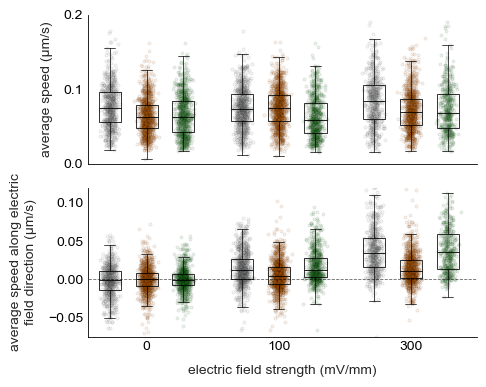

In [177]:
# Assumes df_displacement_mag and df_displacement_proj are already computed
# df_displacement_mag['mean_speed'] = df_displacement_mag['mean_speed'] / (3.0 * 60.0)
# df_displacement_proj['mean_speed'] = df_displacement_proj['mean_dx'] / (3.0 * 60.0)

df_mag_plot = df_displacement_mag[df_displacement_mag.E_V_cm.isin([0, 1, 3])]
df_proj_plot = df_displacement_proj[df_displacement_proj.E_V_cm.isin([0, 1, 3])]

# Settings
E_levels = [0, 1, 3]
celltypes = [wt, ko, res]
colors = [color_dict[wt], color_dict[ko], color_dict[res]]
celltype_color_dict = dict(zip(celltypes, colors))

group_spacing = 0.9
dodge_offset = 0.25
jitter_scale = 0.025
box_width = 0.15

# Setup 2-row figure
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 4), sharex=True)

titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]
datasets = [df_mag_plot, df_proj_plot]

for row, (ax, df_plot, ylabel) in enumerate(zip(axs, datasets, titles)):
    legend_entries = {}
    
    for i, E in enumerate(E_levels):
        x_base = i * group_spacing
        for j, celltype in enumerate(celltypes):
            x_pos = x_base + (j - 1) * dodge_offset
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0.5),
                capprops=dict(color='black', linewidth=0.5),
            )

            # Jittered scatter
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            scatter = ax.scatter(
                jittered_x, speeds,
                s=5, color=celltype_color_dict[celltype],
                alpha=0.1, edgecolor='black', linewidth=0.5,
                label=celltype if (E == 0 and celltype not in legend_entries) else None
            )
            legend_entries[celltype] = scatter

    # Formatting
    xticks = [i * group_spacing for i in range(len(E_levels))]
    xticklabels = [str(e * 100) for e in E_levels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10)
    # ax.set_yticklabels(fontsize=10)
    ax.set_xlim(-0.4, 2.25)
    ax.set_ylabel(ylabel, fontsize=10)
    
    ax.grid(False)

    if ylabel == "average speed (μm/s)":
        yticks = [0,0.1, 0.2]
        ax.set_yticks(yticks)
        ax.set_ylim(0,0.2)
    else:
        ax.hlines(y=0, xmin=-1, xmax=3 + box_width, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
        yticks = [-0.05,0.0, 0.05, 0.1, 0.15]
        ax.set_yticks(yticks)
        ax.set_ylim(-0.075,0.12)

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.6, length=5)
    ax.tick_params(axis='y', labelsize=10) 

# Shared xlabel
axs[1].set_xlabel("electric field strength (mV/mm)", fontsize=10)


# # Optional legend (from top axis)
# handles, labels = axs[0].get_legend_handles_labels()
# unique = dict(zip(labels, handles))
# fig.legend(unique.values(), unique.keys(), title='Cell Type',
           # fontsize=9, title_fontsize=10, loc='upper center', ncol=3)

plt.tight_layout()#rect=[0, 0, 1, 0.95])

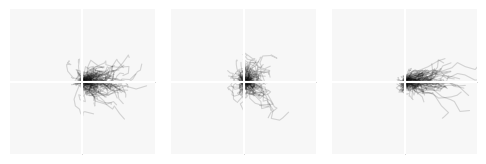

In [169]:
fig, axs = plt.subplots(1, 3, figsize=(5, 6.5))


# ---- Top Row: Relative Trajectories ----
df_traj = df_intervals_3[df_intervals_3.E_V_cm == 3].copy()
celltypes = [wt, ko, res]
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

for i, celltype in enumerate(celltypes):
    ax =axs[i]
    d = df_traj[df_traj.celltype == celltype]
    count_cell = 0

    for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if len(d_) < 5 or count_cell >= 125:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)
        count_cell += 1

    ax.axhline(0, color='white', lw=1.6, zorder=100)
    ax.axvline(0, color='white', lw=1.6, zorder=100)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.set_xlim(-220, 220)
    ax.set_ylim(-220, 220)
    ax.set_aspect('equal')
    ax.set_axisbelow(True)
    ax.set_facecolor('#f7f7f7')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    # ax.set_title(celltype, fontsize=10)

# Add E-field label on leftmost plot
# fig.axes[0].set_ylabel("300 mV/mm", fontsize=10, labelpad=10)
fig.axes[0].yaxis.set_label_coords(-0.2, 0.5)


plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

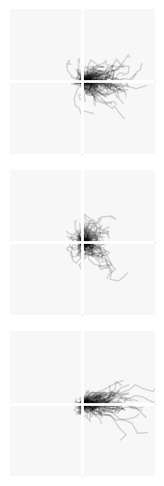

In [170]:
fig, axs = plt.subplots(3,1, figsize=(4, 5))


# ---- Top Row: Relative Trajectories ----
df_traj = df_intervals_3[df_intervals_3.E_V_cm == 3].copy()
celltypes = [wt, ko, res]
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

for i, celltype in enumerate(celltypes):
    ax =axs[i]
    d = df_traj[df_traj.celltype == celltype]
    count_cell = 0

    for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if len(d_) < 5 or count_cell >= 125:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax.plot(x_rel, y_rel, color='black', alpha=0.15, lw=1, zorder=10)
        count_cell += 1

    ax.axhline(0, color='white', lw=2, zorder=100)
    ax.axvline(0, color='white', lw=2, zorder=100)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.set_xlim(-220, 220)
    ax.set_ylim(-220, 220)
    ax.set_aspect('equal')
    ax.set_axisbelow(True)
    ax.set_facecolor('#f7f7f7')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    # ax.set_title(celltype, fontsize=10)

# Add E-field label on leftmost plot
# fig.axes[0].set_ylabel("300 mV/mm", fontsize=10, labelpad=10)
fig.axes[0].yaxis.set_label_coords(-0.2, 0.5)


plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

In [229]:
# df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
# df_temp = df_temp[df_temp.date == 20240313]
# df_temp = df_temp[df_temp.user == 'HK']
# df_temp = df_temp[df_temp.E_V_cm == 3]
# df_temp = df_temp[df_temp.trial == 1]

# df_temp = df[df.celltype == 'dHL60TMEM154KO']
# df_temp = df_temp[df_temp.date == 20240320]
# df_temp = df_temp[df_temp.user == 'TE']
# df_temp = df_temp[df_temp.E_V_cm == 3]
# df_temp = df_temp[df_temp.trial == 1]

# df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
# df_temp = df_temp[df_temp.date == 20240313]
# df_temp = df_temp[df_temp.user == 'HK']
# df_temp = df_temp[df_temp.E_V_cm == 3]
# df_temp = df_temp[df_temp.trial == 1]



# fig, axs = plt.subplots(3,1, figsize=(4, 5))


# # ---- Top Row: Relative Trajectories ----
# df_traj = df_intervals_3[df_intervals_3.E_V_cm == 3].copy()
# celltypes = [wt, ko, res]
# celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

# for i, celltype in enumerate(celltypes):
#     ax =axs[i]
#     d = df_traj[df_traj.celltype == celltype]
    
#     if celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
#         d = d[d.date == 20240313]
#         d = d[d.user == 'HK']
#         d = d[d.trial == 1]
#     elif celltype == 'dHL60TMEM154KO':
#         d = d[d.date == 20240320]
#         d = d[d.user == 'TE']
#         d = d[d.trial == 1]
#     elif celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
#         d = d[d.date == 20240313]
#         d = d[d.user == 'HK']
#         d = d[d.trial == 1]

#     count_cell = 0

#     for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
#         if len(d_) < 5 or count_cell >= 125:
#             continue

#         t0_x = d_[d_.frame == d_.frame.min()].x.values
#         t0_y = d_[d_.frame == d_.frame.min()].y.values
#         if len(t0_x) == 0 or len(t0_y) == 0:
#             continue

#         x_rel = d_.x.values - t0_x[0]
#         y_rel = d_.y.values - t0_y[0]

#         ax.plot(x_rel, y_rel, color='black', alpha=0.15, lw=1, zorder=10)
#         count_cell += 1

#     ax.axhline(0, color='white', lw=2, zorder=100)
#     ax.axvline(0, color='white', lw=2, zorder=100)
#     ax.spines['left'].set_position(('data', 0))
#     ax.spines['bottom'].set_position(('data', 0))
#     ax.set_xlim(-250, 250)
#     ax.set_ylim(-250, 250)
#     ax.set_aspect('equal')
#     ax.set_axisbelow(True)
#     ax.set_facecolor('#f7f7f7')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.tick_params(left=False, bottom=False)
#     # ax.set_title(celltype, fontsize=10)

# # Add E-field label on leftmost plot
# # fig.axes[0].set_ylabel("300 mV/mm", fontsize=10, labelpad=10)
# fig.axes[0].yaxis.set_label_coords(-0.2, 0.5)


# plt.tight_layout()#rect=[0, 0, 1, 0.95])



### Statistics to compare the mean values

In [70]:
# print('0 mV/mm electric field condition')

# count = 0
# for E, df_temp in df_filtered_tracks.groupby('E_V_cm'):
#     if E != 0:
#         continue
         
#     count_int_kw = 0
#     count_cell_kw = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60KW'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         print(g)

#         dot_kw = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             tot = 0
#             for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                 vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                           d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                 tot += vec_t1[0]
#                 count_int_kw += 1
#             dot_kw = np.append(dot_kw,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))
                
#         count_cell_kw += 1
#     print('wild-type')
#     print('num. cells: ', count_cell_kw)
#     print('num. intervals: ', count_int_kw)
    
#     count_int_ko = 0
#     count_cell_ko = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60TMEM154KO'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         print(g)

#         dot_ko = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             tot = 0
#             for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                 vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                           d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                 tot += vec_t1[0]
#                 count_int_ko += 1
#             dot_ko = np.append(dot_ko,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))
                
#         count_cell_ko += 1
            
#     print('knockout')
#     print('num. cells: ', count_cell_ko)
#     print('num. intervals: ', count_int_ko)
#     count_int_res = 0
#     count_cell_res = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         print(g)
        
#         dot_res = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             tot = 0
#             for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                 vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                           d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                 tot += vec_t1[0]
#                 count_int_res += 1
#             dot_res = np.append(dot_res,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))

#         count_cell_res += 1
#     print('rescue')
#     print('num. cells: ', count_cell_res)
#     print('num. intervals: ', count_int_res)    

# print(' ')

# df_treat = dot_res
# df_control = dot_kw
# print('res_wt', mannwhitneyu(df_treat, df_control))   

# df_treat = dot_ko
# df_control = dot_kw
# print('ko_wt', mannwhitneyu(df_treat, df_control))   

# ############################################
# ############################################
# ############################################

# print('300 mV/mm electric field condition')

# count = 0
# for E, df_temp in df.groupby('E_V_cm'):
#     if E != 3:
#         continue
         
#     count_int_kw = 0
#     count_cell_kw = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60KW'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         print(g)

#         dot_kw = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             tot = 0
#             for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                 vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                           d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                 tot += vec_t1[0]
#                 count_int_kw += 1
#             dot_kw = np.append(dot_kw,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))
                
#         count_cell_kw += 1
#     print('wild-type')
#     print('num. cells: ', count_cell_kw)
#     print('num. intervals: ', count_int_kw)
    
#     count_int_ko = 0
#     count_cell_ko = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60TMEM154KO'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         print(g)

#         dot_ko = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             tot = 0
#             for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                 vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                           d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                 tot += vec_t1[0]
#                 count_int_ko += 1
#             dot_ko = np.append(dot_ko,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))
                
#         count_cell_ko += 1
            
#     print('knockout')
#     print('num. cells: ', count_cell_ko)
#     print('num. intervals: ', count_int_ko)
#     count_int_res = 0
#     count_cell_res = 0
#     for g, d in df_temp[df_temp.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA'].groupby(['celltype',  'E_V_cm'],  sort=False):
#         print(g)
        
#         dot_res = []
#         for cell, d_ in d.groupby(['date', 'trial', 'user', 'cell']):
#             tot = 0
#             for t in np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]:
#                 vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
#                           d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0]]
#                 tot += vec_t1[0]
#                 count_int_res += 1
#             dot_res = np.append(dot_res,tot/len(np.arange(d_.frame.min(),d_.frame.max(), 3)[1:]))

#         count_cell_res += 1
#     print('rescue')
#     print('num. cells: ', count_cell_res)
#     print('num. intervals: ', count_int_res)     

# print(' ')

# df_treat = dot_res
# df_control = dot_kw
# print('res_wt', mannwhitneyu(df_treat, df_control))   

# df_treat = dot_ko
# df_control = dot_kw
# print('ko_wt', mannwhitneyu(df_treat, df_control))  

# 0 mV/mm electric field condition
# ('dHL60KW', 0)
# wild-type
# num. cells:  1
# num. intervals:  5646
# ('dHL60TMEM154KO', 0)
# knockout
# num. cells:  1
# num. intervals:  9341
# ('dHL60TMEM154KO-clone1galvanin-GFP-HA', 0)
# rescue
# num. cells:  1
# num. intervals:  6975
# res_wt MannwhitneyuResult(statistic=272950.0, pvalue=0.3102595939282806)
# ko_wt MannwhitneyuResult(statistic=378798.0, pvalue=0.25050444193511934)
# 300 mV/mm electric field condition
# ('dHL60KW', 3)
# wild-type
# num. cells:  1
# num. intervals:  5032
# ('dHL60TMEM154KO', 3)
# knockout
# num. cells:  1
# num. intervals:  8985
# ('dHL60TMEM154KO-clone1galvanin-GFP-HA', 3)
# rescue
# num. cells:  1
# num. intervals:  4116
 
# res_wt MannwhitneyuResult(statistic=146048.0, pvalue=0.8135462560597002)
# ko_wt MannwhitneyuResult(statistic=165792.0, pvalue=2.3916559429765507e-58)


def compute_x_speed_stats(df_intervals_3, field_strength):
    print(f"{field_strength*100} mV/mm electric field condition")

    dot_kw, dot_ko, dot_res = [], [], []

    for celltype, dot_list in [
        ('dHL60KW', dot_kw),
        ('dHL60TMEM154KO', dot_ko),
        ('dHL60TMEM154KO-clone1galvanin-GFP-HA', dot_res),
    ]:
        subset = df_intervals_3[
            (df_intervals_3.E_V_cm == field_strength) &
            (df_intervals_3.celltype == celltype)
        ]

        for _, d in subset.groupby(['date', 'trial', 'user', 'cell']):
            if len(d) <= 1:
                continue
            d = d.sort_values('interval')
            dx = np.diff(d['x'].values)

            # Compute x-speed in μm/sec
            x_speed = dx / 180.0  # since 3 frames = 180 sec
            if len(x_speed) == 0:
                continue
            mean_x_speed = np.mean(x_speed)
            dot_list.append(mean_x_speed)

    # Count and display
    print('wild-type')
    print('num. cells:', len(dot_kw))
    print('mean speed x [μm/s]:', np.mean(dot_kw))
    print()

    print('knockout')
    print('num. cells:', len(dot_ko))
    print('mean speed x [μm/s]:', np.mean(dot_ko))
    print()

    print('rescue')
    print('num. cells:', len(dot_res))
    print('mean speed x [μm/s]:', np.mean(dot_res))
    print()

    # Mann–Whitney U tests
    print('res_wt', mannwhitneyu(dot_res, dot_kw, alternative='two-sided'))
    print('ko_wt', mannwhitneyu(dot_ko, dot_kw, alternative='two-sided'))
    print('\n' + '#' * 40 + '\n')

# Run comparisons
compute_displacement_stats(df_intervals_3, field_strength=0)
compute_displacement_stats(df_intervals_3, field_strength=3)

0 mV/mm electric field condition
wild-type
num. cells:  667
num. intervals:  5972
knockout
num. cells:  1100
num. intervals:  9782
rescue
num. cells:  794
num. intervals:  7725
 
res_wt MannwhitneyuResult(statistic=269985.0, pvalue=0.5185664732416381)
ko_wt MannwhitneyuResult(statistic=379534.0, pvalue=0.22249733852639997)

########################################

300 mV/mm electric field condition
wild-type
num. cells:  591
num. intervals:  5262
knockout
num. cells:  1038
num. intervals:  9407
rescue
num. cells:  474
num. intervals:  4510
 
res_wt MannwhitneyuResult(statistic=141849.0, pvalue=0.7210015027671062)
ko_wt MannwhitneyuResult(statistic=159177.0, pvalue=9.053866134910089e-59)

########################################



# Plots to illustrate 3D tracks

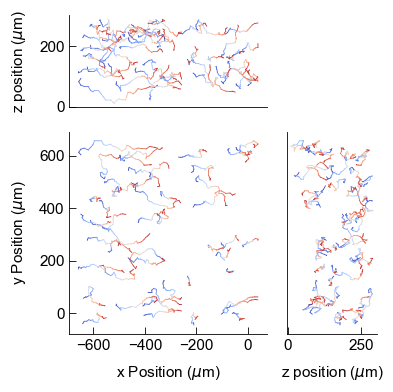

In [7]:
# 20240211_dHL60KW_3Vcm_1_user_NB_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60KW']
df_temp = df_temp[df_temp.date == 20240211]
df_temp = df_temp[df_temp.user == 'NB']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()

ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)


fig = plt.figure(figsize=(4,4))

gs = gridspec.GridSpec(2, 2,height_ratios=[1,(1024.0*ip)/300], width_ratios=[(1024.0*ip)/300,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])
ax3 = plt.subplot(gs[3])

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red
        
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x - 1024.0*ip
    y = 1024.0*ip - d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax1.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
#     ax1.set_ylim(0,300)
#     ax1.set_xlim(-676,0)  
    ax1.set_ylabel('z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax2.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax2.set_xlabel('x Position ($\mu$m)')
    ax2.set_ylabel('y Position ($\mu$m)')
#     ax2.set_xlim(0,-676)
#     ax2.set_ylim(0,676)  
    
    for i in range(len(x) - 1):
        ax3.plot(z[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax3.set_xlabel('z position ($\mu$m)')
#     ax3.set_xlim(0,300)
#     ax3.set_ylim(0,676)
        

    ax1.xaxis.set_visible(False)
    ax3.yaxis.set_visible(False)


plt.tight_layout()

# plt.savefig('../../figures/Figure3_tracks_WT.pdf')


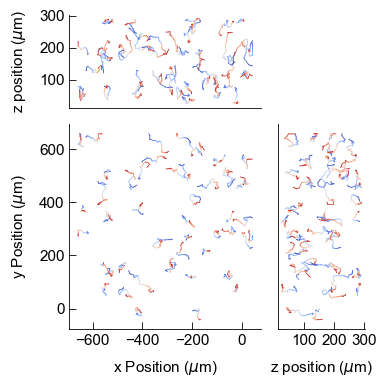

In [8]:
# 20240320_dHL60TMEM154KO-clone1_3Vcm_1_user_TE_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60TMEM154KO']
df_temp = df_temp[df_temp.date == 20240320]
df_temp = df_temp[df_temp.user == 'TE']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]


df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()



ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)


fig = plt.figure(figsize=(4,4))

gs = gridspec.GridSpec(2, 2,height_ratios=[1,(1024.0*ip)/300], width_ratios=[(1024.0*ip)/300,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])
ax3 = plt.subplot(gs[3])

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red


for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x - 1024.0*ip
    y = 1024.0*ip - d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax1.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
#     ax1.set_ylim(0,300)
#     ax1.set_xlim(-676,0)  
    ax1.set_ylabel('z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax2.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax2.set_xlabel('x Position ($\mu$m)')
    ax2.set_ylabel('y Position ($\mu$m)')
#     ax2.set_xlim(0,-676)
#     ax2.set_ylim(0,676)  
    
    for i in range(len(x) - 1):
        ax3.plot(z[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax3.set_xlabel('z position ($\mu$m)')
#     ax3.set_xlim(0,300)
#     ax3.set_ylim(0,676)
        

    ax1.xaxis.set_visible(False)
    ax3.yaxis.set_visible(False)


plt.tight_layout()


# Add a colorbar to the first subplot
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
# sm.set_array([])
# fig.colorbar(sm, ax=ax2, orientation='vertical', label='Time')

# plt.savefig('../../figures/Figure3_tracks_KO.pdf')

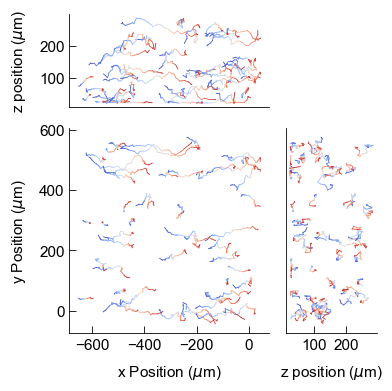

In [9]:
# 20240313_dHL60TMEM154KO-clone1galvanin-GFP-HA_3Vcm_1_user_HK_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]


df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    

ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)



fig = plt.figure(figsize=(4,4))

gs = gridspec.GridSpec(2, 2,height_ratios=[1,(1024.0*ip)/300], width_ratios=[(1024.0*ip)/300,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])
ax3 = plt.subplot(gs[3])

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x - 1024.0*ip
    y = 1024.0*ip - d_.y
    z = d_.z
    time = np.arange(len(x))

    
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax1.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
#     ax1.set_ylim(0,300)
#     ax1.set_xlim(-676,0)  
    ax1.set_ylabel('z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax2.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax2.set_xlabel('x Position ($\mu$m)')
    ax2.set_ylabel('y Position ($\mu$m)')
#     ax2.set_xlim(0,-676)
#     ax2.set_ylim(0,676)  
    
    for i in range(len(x) - 1):
        ax3.plot(z[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax3.set_xlabel('z position ($\mu$m)')
#     ax3.set_xlim(0,300)
#     ax3.set_ylim(0,676)
        

    ax1.xaxis.set_visible(False)
    ax3.yaxis.set_visible(False)




plt.tight_layout()


# Add a colorbar to the first subplot
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
# sm.set_array([])
# fig.colorbar(sm, ax=ax2, orientation='vertical', label='Time')

# plt.savefig('../../figures/Figure3_tracks_rescue.pdf')


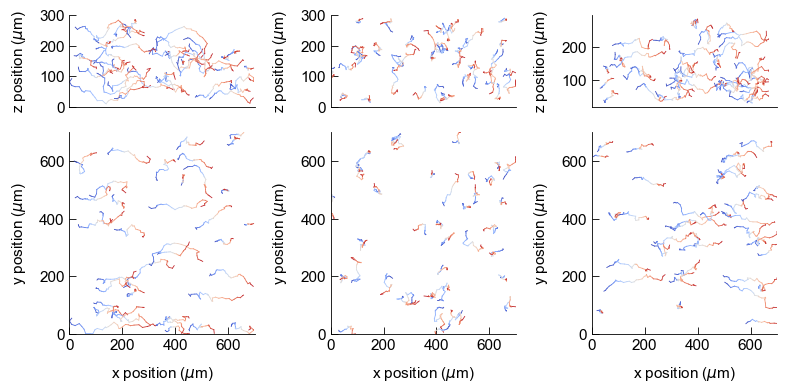

In [12]:
fig = plt.figure(figsize=(8,4))

gs = gridspec.GridSpec(2, 3,height_ratios=[1,(1024.0*ip)/300])

###########################
###########################
# a
###########################
###########################
ax_wt_xz = plt.subplot(gs[0])
ax_wt_xy = plt.subplot(gs[3])


# 20240211_dHL60KW_3Vcm_1_user_NB_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60KW']
df_temp = df_temp[df_temp.date == 20240211]
df_temp = df_temp[df_temp.user == 'NB']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()

ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    if count == 40:
        continue

    x = d_.x 
    y = d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax_wt_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xz.set_ylim(0,300)
    ax_wt_xz.set_xlim(0,700)  
    ax_wt_xz.set_ylabel('z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_wt_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xy.set_xlabel('x position ($\mu$m)')
    ax_wt_xy.set_ylabel('y position ($\mu$m)')
    ax_wt_xy.set_xlim(0,700)
    ax_wt_xy.set_ylim(0,700)  
    

    ax_wt_xz.xaxis.set_visible(False)
    count += 1
    

#############################
###########################
# b
###########################
###########################

ax_ko_xz = plt.subplot(gs[1])
ax_ko_xy = plt.subplot(gs[4])


df_temp = df[df.celltype == 'dHL60TMEM154KO']
df_temp = df_temp[df_temp.date == 20240320]
# df_temp = df_temp[df_temp.date == 20240229]
df_temp = df_temp[df_temp.user == 'TE']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]


df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)


ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    if count == 40:
        continue

    x = d_.x
    y = d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax_ko_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_ko_xz.set_ylim(0,300)
    ax_ko_xz.set_xlim(0,700) 
    ax_ko_xz.set_ylabel('z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_ko_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_ko_xy.set_xlabel('x position ($\mu$m)')
    ax_ko_xy.set_ylabel('y position ($\mu$m)')
    ax_ko_xy.set_xlim(0,700)
    ax_ko_xy.set_ylim(0,700)  
    
    ax_ko_xz.xaxis.set_visible(False)
    count += 1

    
###########################
###########################
# c
###########################
###########################
ax_res_xz = plt.subplot(gs[2])
ax_res_xy = plt.subplot(gs[5])

df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]


df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 30):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()


ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

# random_50_numbers = random.sample(d.cell.unique().tolist() , 50)
random_50_numbers = random.sample(d.cell.unique().tolist() , 100)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    if count == 40:
        continue
    elif np.any([x< 10 for x in d_.z.values]):
        continue

    x = d_.x 
    y = d_.y 
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax_res_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax1.set_ylim(0,300)
    ax1.set_xlim(0,700)  
    ax_res_xz.set_ylabel('z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_res_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_res_xy.set_xlabel('x position ($\mu$m)')
    ax_res_xy.set_ylabel('y position ($\mu$m)')
    ax_res_xy.set_xlim(0,700)
    ax_res_xy.set_ylim(0,700)  
    

    ax_res_xz.xaxis.set_visible(False)

    count += 1
    
    
plt.tight_layout()

plt.savefig('../../figures/Figure2_draft1_tracks_3.pdf')


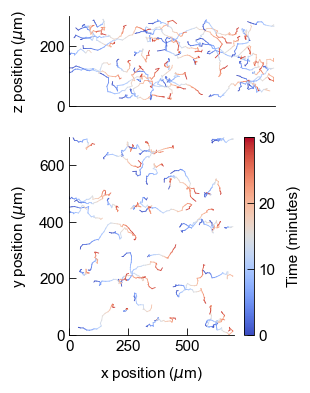

In [6]:

fig = plt.figure(figsize=(8, 4))

gs = gridspec.GridSpec(2, 3, height_ratios=[1, (1024.0 * 0.642) / 300])

###########################
###########################
# a
###########################
###########################
ax_wt_xz = plt.subplot(gs[0])
ax_wt_xy = plt.subplot(gs[3])

# Filter the DataFrame
df_temp = df[df.celltype == 'dHL60KW']
df_temp = df_temp[df_temp.date == 20240211]
df_temp = df_temp[df_temp.user == 'NB']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()

ip = 0.642  # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist(), 50)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

for c, d_ in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x 
    y = d_.y
    z = d_.z
    time = np.arange(d_.frame.min(), d_.frame.max())
    
    # Normalize the time array to range from 0 to 1 based on a fixed range of 0 to 30 minutes
    norm_time = (time - np.min(time)) / (30.0)  # 30 minutes max

    for i in range(len(x) - 1):
        ax_wt_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xz.set_ylim(0, 300)
    ax_wt_xz.set_xlim(0, 700)  
    ax_wt_xz.set_ylabel('z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_wt_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xy.set_xlabel('x position ($\mu$m)')
    ax_wt_xy.set_ylabel('y position ($\mu$m)')
    ax_wt_xy.set_xlim(0, 700)
    ax_wt_xy.set_ylim(0, 700)  

    ax_wt_xz.xaxis.set_visible(False)

# Add a colorbar to the first subplot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=30))  # 0 to 30 minutes
sm.set_array([])

# Set the ticks and labels for the colorbar
tick_positions = np.linspace(0, 30, num=4)  # Ticks at every 10 minutes (0, 10, 20, 30)
tick_labels = np.arange(0, 31, 10)  # Labels from 0 to 30 minutes at 10-minute intervals

cbar = fig.colorbar(sm, ax=ax_wt_xy, orientation='vertical', label='Time (minutes)')
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(tick_labels)

plt.tight_layout()

# plt.savefig('../../figures/Figure3_draft1_colormap.pdf')

# Average speed calculations

0
dHL60KW
[0.10777527 0.03355614 0.10197967 0.03645745 0.09476819 0.09374405
 0.1284426  0.15489066 0.07744304 0.0348415  0.07658918 0.02647141
 0.11710041 0.04970025 0.07005548 0.06666836 0.08708467 0.10445174
 0.09492695 0.10833842 0.14475833 0.03007289 0.02948274 0.17119707
 0.09792024 0.10853231 0.05412999 0.07242234 0.08850487 0.1325152
 0.14239339 0.10609148 0.10664197 0.07606939 0.09339654 0.05526797
 0.06691096 0.04594078 0.14585696 0.08464798 0.13975683 0.06435176
 0.04162797 0.10668667 0.14020821 0.0630663  0.10661554 0.08853186
 0.08437688 0.07018081 0.06759739 0.05284776 0.03844109 0.08788772
 0.05343395 0.06748271 0.04883462 0.09431408 0.16089835 0.09207486
 0.09239185 0.09295538 0.04054866 0.09139725 0.12199062 0.04735892
 0.03126479 0.09163347 0.11166128 0.06119266 0.10031785 0.21013582
 0.08423331 0.09241456 0.06725746 0.11400431 0.09765752 0.08478995
 0.06500215 0.07156475 0.09349038 0.10819288 0.04701451 0.04413461
 0.08779496 0.06849115 0.05235563 0.0919282  0.164355

KeyboardInterrupt: 

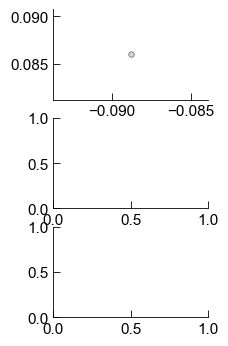

In [104]:
celllines = df.celltype.unique() 
colors = sns.color_palette("tab10")
color_dict = dict(zip(df.celltype.unique(), colors))    
color_dict.update({'dHL60KW':'#B8BABC'})


fig, ax = plt.subplots(3,1, figsize = (2, 4))

celltype_dict = dict(zip(df_filtered_tracks.celltype.unique(), np.arange(len(df_filtered_tracks.celltype.unique()))))
axes_dict = dict(zip([0, 1, 3], [0, 1, 2]))

vp_3d_s = np.empty_like(np.array(ax))

for E, df_ in df_filtered_tracks[df_filtered_tracks.E_V_cm != 5].groupby('E_V_cm'):
    print(E)
    for c, df_temp in df_.groupby('celltype'):
        print(c)
        ind = celltype_dict[c]
        speed_all = []
        color = color_dict[c]
        
        for g, d in df_temp.groupby(['date', 'trial', 'user'], sort=False):
            speed_prep = []
            
            for cell, d_ in d.groupby('cell'):
                speed_cell = []
                frames = d_['frame'].values
                available = set(frames)
                
                for t in frames:
                    if (t - 3) in available:
                        p1 = d_.loc[d_['frame'] == t, ['x', 'y', 'z']].values[0]
                        p0 = d_.loc[d_['frame'] == t - 3, ['x', 'y', 'z']].values[0]
                        dist = np.linalg.norm(p1 - p0)
                        speed = dist / 180.0
                        speed_cell.append(speed)

        
                # for t in np.arange(d_.frame.min(), d_.frame.max(), 3)[1:]:
                #     vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
                #               d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0],
                #               d_[d_.frame == t].z.values[0] - d_[d_.frame == t-3].z.values[0]]
                #     speed_cell = np.append(speed_cell, np.sqrt(vec_t1[0]**2 + vec_t1[1]**2 + vec_t1[2]**2) / (3*60))

                speed_prep = np.append(speed_prep, np.mean(speed_cell)) 
            print(speed_prep)

            # Add random jitter to the x-coordinate
            jitter = np.random.uniform(-0.1, 0.1)
            x_position = celltype_dict[c] + jitter
            
            ax[axes_dict[E]].errorbar(x_position, np.mean(speed_prep),
                                      markersize=4, marker='o', color=color,
                                      markeredgecolor='k',
                                      markeredgewidth=0.5,
                                      lw=0.5,
                                      alpha=0.6, zorder=10)   

            speed_all = np.append(speed_all, speed_prep)
            print(len(speed_prep), np.mean(speed_prep))

        vp_3d_s = ax[axes_dict[E]].violinplot(speed_all, positions=[celltype_dict[c]], points=60, widths=0.3,
                                              showmeans=False, showextrema=False, showmedians=False,
                                              bw_method=0.2)
        
        
        
        
        for pc in vp_3d_s['bodies']:
            pc.set_color(color)
            pc.set_alpha(0.5) #0.75
            pc.set_zorder(0)

        ax[axes_dict[E]].hlines(speed_all.mean(), celltype_dict[c]-0.15, celltype_dict[c]+0.15, zorder=10, lw=1.5, color='k')

        ax[axes_dict[E]].set_xlim(-0.5, 2.5)
        ax[axes_dict[E]].xaxis.set_visible(False)
        ax[axes_dict[E]].set_ylim(0, 0.2)
        ax[axes_dict[E]].set_yticks([0.0, 0.1, 0.2])
        ax[axes_dict[E]].set_ylabel('average speed\n' + r'($\mu$m/s)')

# plt.savefig('../../figures/Figure3_avg_speeds_.pdf')


# 0
# dHL60KW
# 0.08531550280951188
# 0.07636640185317524
# 0.08865657147820691
# 0.05592689893996767
# dHL60TMEM154KO
# 0.07714672407331437
# 0.06509583070157175
# 0.05997728907269512
# 0.06299053715464098
# 0.056650006923257716
# 0.06942555155253785
# 0.06289349406384145
# dHL60TMEM154KO-clone1galvanin-GFP-HA
# 0.062017746839503014
# 0.030024673874601154
# 0.04645298964799395
# 0.07187163486468967
# 0.07569439619041407
# 0.08759163447388049
# 0.07610841492562864
# 0.051695684277266785
# 0.05012211993983101
# 1
# dHL60KW
# 0.07920830249735004
# 0.0675895348977802
# 0.06741273547423599
# 0.09304940546444582
# 0.058807808240727705
# 0.07064212348726237
# dHL60TMEM154KO
# 0.06571700938285434
# 0.07207234723958475
# 0.08102524301546031
# 0.07928545358456916
# 0.07901660977750033
# 0.07186318792046964
# 0.08028892026468282
# 0.07223217550717433
# dHL60TMEM154KO-clone1galvanin-GFP-HA
# 0.04041835176030825
# 0.055112294451832605
# 0.08388795390373849
# 0.07536017950371475
# 0.07804914287126441
# 0.05889808818546876
# 0.054971201699159165
# 3
# dHL60KW
# 0.10969991390297808
# 0.07164881635986206
# 0.08041048585422268
# 0.08529441761705836
# dHL60TMEM154KO
# 0.08046032919152492
# 0.07078096869812592
# 0.06161734326724775
# 0.0639917374355793
# 0.07160269779248069
# 0.07998516494971271
# 0.07924301596967935
# dHL60TMEM154KO-clone1galvanin-GFP-HA
# 0.07170416447690382
# 0.06745528981464918
# 0.05765939021121014
# 0.053591630650228574
# 0.09374381957033823
# 0.06692438795409714


0 V/cm
  dHL60KW: 134 cells, mean 0.0858
  dHL60KW: 179 cells, mean 0.0758
  dHL60KW: 206 cells, mean 0.0885
  dHL60KW: 148 cells, mean 0.0556
  dHL60TMEM154KO: 107 cells, mean 0.0773
  dHL60TMEM154KO: 228 cells, mean 0.0652
  dHL60TMEM154KO: 54 cells, mean 0.0598
  dHL60TMEM154KO: 252 cells, mean 0.0630
  dHL60TMEM154KO: 137 cells, mean 0.0570
  dHL60TMEM154KO: 218 cells, mean 0.0687
  dHL60TMEM154KO: 104 cells, mean 0.0629
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 34 cells, mean 0.0628
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 56 cells, mean 0.0311
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 31 cells, mean 0.0472
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 88 cells, mean 0.0711
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 199 cells, mean 0.0762
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 74 cells, mean 0.0887
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 114 cells, mean 0.0762
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 98 cells, mean 0.0522
  dHL60TMEM154KO-clone1galvanin-GFP-HA: 100 cells, mean 0.0505

1 V/cm
 

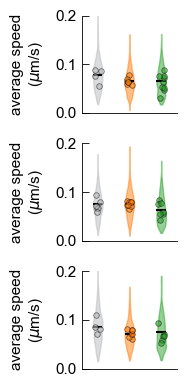

In [105]:
fig, ax = plt.subplots(3, 1, figsize=(2, 4))

celltypes = sorted(df_intervals_3['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))))
field_strengths = sorted(df_intervals_3['E_V_cm'].unique())
field_strengths = [e for e in field_strengths if e != 5]  # exclude 5 V/cm

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals_3[df_intervals_3.E_V_cm == E]
    print(f"\n{E} V/cm")

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                # Use 2D or 3D displacement depending on z availability
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values

                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / 180.0  # μm/sec
                

                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))
            # print(speed_prep)

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=10
                )
                speed_all.extend(speed_prep)
                print(f"  {celltype}: {len(speed_prep)} cells, mean {np.mean(speed_prep):.4f}")

        # Plot violin if there’s data
        if len(speed_all) > 0:
            vp = ax[ax_idx].violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                              color='k', lw=1.5, zorder=10)

# Style all axes
for a in ax:
    a.set_xlim(-0.5, len(celltypes) - 0.5)
    a.set_ylim(0, 0.2)
    a.set_yticks([0.0, 0.1, 0.2])
    a.set_ylabel('average speed\n' + r'($\mu$m/s)')
    a.xaxis.set_visible(False)

plt.tight_layout()
# plt.savefig('../../figures/Figure3_avg_speeds_updated.pdf')

### perform statisics

In [109]:
# Filter for 0 V/cm condition
df_zero = df_intervals_3[df_intervals_3.E_V_cm == 0]

# Output containers
speed_all_kw, speed_all_ko, speed_all_res = [], [], []

# Group by cell type
for celltype, df_cell in df_zero.groupby('celltype'):
    speed_per_trial = []

    for _, trial_df in df_cell.groupby(['date', 'trial', 'user'], sort=False):
        speed_per_cell = []

        for _, d in trial_df.groupby('cell'):
            d = d.sort_values('interval')
            if len(d) <= 1:
                continue

            # Ensure z is present and clean
            if 'z' not in d.columns or d['z'].isnull().any():
                continue

            pos = d[['x', 'y', 'z']].values
            dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
            speeds = dists / 180.0  # μm/sec assuming 3 frames = 180 sec

            if len(speeds) > 0:
                speed_per_cell.append(np.mean(speeds))

        # Store trial average
        if len(speed_per_cell) > 0:
            trial_mean = np.mean(speed_per_cell)
            speed_per_trial.append(trial_mean)

    # Assign to correct group
    if celltype == 'dHL60KW':
        speed_all_kw = speed_per_trial
    elif celltype == 'dHL60TMEM154KO':
        speed_all_ko = speed_per_trial
    elif celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
        speed_all_res = speed_per_trial


# KO vs WT
print('KO vs WT:', mannwhitneyu(speed_all_ko, speed_all_kw, alternative='two-sided'))

# Rescue vs WT
print('Rescue vs WT:', mannwhitneyu(speed_all_res, speed_all_kw, alternative='two-sided'))


KO vs WT: MannwhitneyuResult(statistic=8.0, pvalue=0.3151515151515151)
Rescue vs WT: MannwhitneyuResult(statistic=10.0, pvalue=0.2601398601398601)


In [111]:
# Filter for 1 V/cm condition
df_one = df_intervals_3[df_intervals_3.E_V_cm == 1]

# Output containers
speed_all_kw, speed_all_ko, speed_all_res = [], [], []

# Group by cell type
for celltype, df_cell in df_one.groupby('celltype'):
    speed_per_trial = []

    for _, trial_df in df_cell.groupby(['date', 'trial', 'user'], sort=False):
        speed_per_cell = []

        for _, d in trial_df.groupby('cell'):
            d = d.sort_values('interval')
            if len(d) <= 1:
                continue

            if 'z' not in d.columns or d['z'].isnull().any():
                continue

            pos = d[['x', 'y', 'z']].values
            dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
            speeds = dists / 180.0  # μm/sec assuming 3 frames = 180 sec

            if len(speeds) > 0:
                speed_per_cell.append(np.mean(speeds))

        if len(speed_per_cell) > 0:
            trial_mean = np.mean(speed_per_cell)
            speed_per_trial.append(trial_mean)

    if celltype == 'dHL60KW':
        speed_all_kw = speed_per_trial
    elif celltype == 'dHL60TMEM154KO':
        speed_all_ko = speed_per_trial
    elif celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
        speed_all_res = speed_per_trial


# KO vs WT
print('KO vs WT:', mannwhitneyu(speed_all_ko, speed_all_kw, alternative='two-sided'))

# Rescue vs WT
print('Rescue vs WT:', mannwhitneyu(speed_all_res, speed_all_kw, alternative='two-sided'))


KO vs WT: MannwhitneyuResult(statistic=31.0, pvalue=0.4135864135864136)
Rescue vs WT: MannwhitneyuResult(statistic=14.0, pvalue=0.36596736596736595)


In [121]:
for E, df_ in df_filtered_tracks[df_filtered_tracks.E_V_cm == 3].groupby('E_V_cm'):
    print(E)
    for c, df_temp in df_.groupby('celltype'):
        if c == 'dHL60KW':
            speed_all_kw = []
            for g, d in df_temp.groupby(['date', 'trial', 'user'], sort=False):
                speed_prep = []
                for cell, d_ in d.groupby('cell'):
                    if len(d_.frame.unique()) > 16:
                        speed_cell = []
                        for t in np.arange(d_.frame.min(), d_.frame.max(), 3)[1:]:
                            vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
                                      d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0],
                                      d_[d_.frame == t].z.values[0] - d_[d_.frame == t-3].z.values[0]]
                            speed_cell = np.append(speed_cell, np.sqrt(vec_t1[0]**2 + vec_t1[1]**2 + vec_t1[2]**2) / (3*60))
    
                    speed_prep = np.append(speed_prep, np.mean(speed_cell)) 
                speed_all_kw = np.append(speed_all_kw, np.mean(speed_prep))
                
        if c == 'dHL60TMEM154KO':
            speed_all_ko = []
            for g, d in df_temp.groupby(['date', 'trial', 'user'], sort=False):
                speed_prep = []
                for cell, d_ in d.groupby('cell'):
                    if len(d_.frame.unique()) > 16:
                        speed_cell = []
                        for t in np.arange(d_.frame.min(), d_.frame.max(), 3)[1:]:
                            vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
                                      d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0],
                                      d_[d_.frame == t].z.values[0] - d_[d_.frame == t-3].z.values[0]]
                            speed_cell = np.append(speed_cell, np.sqrt(vec_t1[0]**2 + vec_t1[1]**2 + vec_t1[2]**2) / (3*60))
    
                    speed_prep = np.append(speed_prep, np.mean(speed_cell)) 
                speed_all_ko = np.append(speed_all_ko, np.mean(speed_prep))
                
        if c == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
            speed_all_res = []
            for g, d in df_temp.groupby(['date', 'trial', 'user'], sort=False):
                speed_prep = []
                for cell, d_ in d.groupby('cell'):
                    if len(d_.frame.unique()) > 16:
                        speed_cell = []
                        for t in np.arange(d_.frame.min(), d_.frame.max(), 3)[1:]:
                            vec_t1 = [d_[d_.frame == t].x.values[0] - d_[d_.frame == t-3].x.values[0],
                                      d_[d_.frame == t].y.values[0] - d_[d_.frame == t-3].y.values[0],
                                      d_[d_.frame == t].z.values[0] - d_[d_.frame == t-3].z.values[0]]
                            speed_cell = np.append(speed_cell, np.sqrt(vec_t1[0]**2 + vec_t1[1]**2 + vec_t1[2]**2) / (3*60))
    
                    speed_prep = np.append(speed_prep, np.mean(speed_cell)) 
                speed_all_res = np.append(speed_all_res, np.mean(speed_prep))
    
df_treat = speed_all_ko
df_control = speed_all_kw
print('KO_wt', scipy.stats.mannwhitneyu(df_treat, df_control))

df_treat = speed_all_res
df_control = speed_all_kw
print('res_wt', scipy.stats.mannwhitneyu(df_treat, df_control))     

3
KO_wt MannwhitneyuResult(statistic=4.0, pvalue=0.07272727272727272)
res_wt MannwhitneyuResult(statistic=4.0, pvalue=0.11428571428571428)


In [ ]:
3
KO_wt MannwhitneyuResult(statistic=4.0, pvalue=0.07272727272727272)
res_wt MannwhitneyuResult(statistic=4.0, pvalue=0.11428571428571428)


0 V/cm

1 V/cm

3 V/cm


/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_9742/2452144930.py:102: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


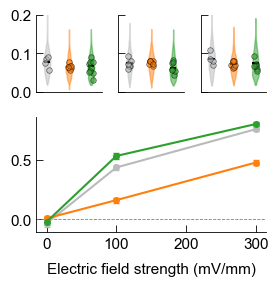

In [145]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df_intervals_3 = df_intervals_3[df_intervals_3.E_V_cm != 5]

# =============================
# Layout: 3 speed violins + 1 cosine directionality plot
# =============================
fig = plt.figure(figsize=(3, 3))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.5])
ax_speed = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_cos = fig.add_subplot(gs[1, :])  # Full-width bottom plot

# -----------------------------
# Speed violin plots
# -----------------------------
celltypes = sorted(df_intervals_3['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))))
field_strengths = [e for e in sorted(df_intervals_3['E_V_cm'].unique()) if e != 5]

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals_3[df_intervals_3.E_V_cm == E]
    print(f"\n{E} V/cm")

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []
    
        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user'], sort=False):
            speed_prep = []
    
            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue
                d = d.sort_values('interval')
    
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values
    
                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / 180.0  # μm/sec
    
                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))
    
            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax_speed[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=10
                )
                speed_all.extend(speed_prep)
    
        # plot 1 violin per celltype
        if len(speed_all) > 0:
            vp = ax_speed[ax_idx].violinplot(
                [speed_all], positions=[ind],  # just 1 dataset per call
                points=60, widths=0.3, showmeans=False,
                showextrema=False, showmedians=False, bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

        ax_speed[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                                color='k', lw=1.5, zorder=10)

    # Style all top-row axes
    for i, a in enumerate(ax_speed):
        a.set_xlim(-0.5, len(celltypes) - 0.5)
        a.set_ylim(0, 0.2)
        a.set_yticks([0.0, 0.1, 0.2])
        # a.set_ylabel('avg. speed\n' + r'($\mu$m/s)' if i == 0 else '')  # Label only first plot
        a.xaxis.set_visible(False)
    
        if i > 0:
            a.tick_params(labelleft=False)  # Hide y-axis tick labels on all but first

# -----------------------------
# Cos(θ) directionality plot
# -----------------------------
def calc_cos_theta_net_per_trajectory(df):
    def cos_theta_net(d):
        dx = d['x'].iloc[-1] - d['x'].iloc[0]
        dy = d['y'].iloc[-1] - d['y'].iloc[0]
        v = np.array([dx, dy])
        e_field = np.array([1, 0])
        norm = np.linalg.norm(v)
        if norm == 0:
            return np.nan
        return np.dot(v, e_field) / norm

    group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']
    return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')

df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_intervals_3)

df_cos_theta_avg = df_cos_theta_net_all.groupby(['celltype', 'E_V_cm']).agg(
    mean_cos_theta_net=('cos_theta_net', 'mean'),
    sem_cos_theta_net=('cos_theta_net', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

for celltype, group in df_cos_theta_avg.groupby('celltype'):
    ax_cos.errorbar(
        group['E_V_cm'] * 100,  # convert to mV/mm
        group['mean_cos_theta_net'],
        yerr=group['sem_cos_theta_net'],
        label=celltype,
        marker='o',
        capsize=2,
        lw=1.5,
        color=color_dict[celltype],
        markersize=4
    )

ax_cos.axhline(0, color='gray', linestyle='--')
ax_cos.set_xlabel('Electric field strength (mV/mm)')
# ax_cos.set_ylabel('Mean cos(θ)\n(net trajectory)')
# ax_cos.legend(title='Cell type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [137]:
color_dict

{'dHL60KW': '#B8BABC',
 'dHL60TMEM154KO': (1.0, 0.4980392156862745, 0.054901960784313725),
 'dHL60TMEM154KO-clone1galvanin-GFP-HA': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313)}

# Updated Plots

## relative tracks @ 300 mV/mm

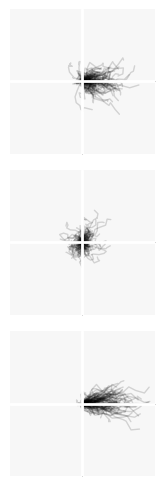

In [230]:
# fig, axs = plt.subplots(3,1, figsize=(4, 5))


# # ---- Top Row: Relative Trajectories ----
# df_traj = df_intervals_3[df_intervals_3.E_V_cm == 3].copy()
# celltypes = [wt, ko, res]
# celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

# for i, celltype in enumerate(celltypes):
#     ax =axs[i]
#     d = df_traj[df_traj.celltype == celltype]
#     count_cell = 0

#     for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
#         if len(d_) < 5 or count_cell >= 125:
#             continue

#         t0_x = d_[d_.frame == d_.frame.min()].x.values
#         t0_y = d_[d_.frame == d_.frame.min()].y.values
#         if len(t0_x) == 0 or len(t0_y) == 0:
#             continue

#         x_rel = d_.x.values - t0_x[0]
#         y_rel = d_.y.values - t0_y[0]

#         ax.plot(x_rel, y_rel, color='black', alpha=0.15, lw=1, zorder=10)
#         count_cell += 1

#     ax.axhline(0, color='white', lw=2, zorder=100)
#     ax.axvline(0, color='white', lw=2, zorder=100)
#     ax.spines['left'].set_position(('data', 0))
#     ax.spines['bottom'].set_position(('data', 0))
#     ax.set_xlim(-220, 220)
#     ax.set_ylim(-220, 220)
#     ax.set_aspect('equal')
#     ax.set_axisbelow(True)
#     ax.set_facecolor('#f7f7f7')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.tick_params(left=False, bottom=False)
#     # ax.set_title(celltype, fontsize=10)

# # Add E-field label on leftmost plot
# # fig.axes[0].set_ylabel("300 mV/mm", fontsize=10, labelpad=10)
# fig.axes[0].yaxis.set_label_coords(-0.2, 0.5)


# plt.tight_layout()#rect=[0, 0, 1, 0.95])




# fig.savefig('../../figures/Figure2_rel_tracks_.pdf')






df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp = df[df.celltype == 'dHL60TMEM154KO']
df_temp = df_temp[df_temp.date == 20240320]
df_temp = df_temp[df_temp.user == 'TE']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]



fig, axs = plt.subplots(3,1, figsize=(4, 5))


# ---- Top Row: Relative Trajectories ----
df_traj = df_intervals_3[df_intervals_3.E_V_cm == 3].copy()
celltypes = [wt, ko, res]
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

for i, celltype in enumerate(celltypes):
    ax =axs[i]
    d = df_traj[df_traj.celltype == celltype]
    
    if celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
        d = d[d.date == 20240313]
        d = d[d.user == 'HK']
        d = d[d.trial == 1]
    elif celltype == 'dHL60TMEM154KO':
        d = d[d.date == 20240320]
        d = d[d.user == 'TE']
        d = d[d.trial == 1]
    elif celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
        d = d[d.date == 20240313]
        d = d[d.user == 'HK']
        d = d[d.trial == 1]

    count_cell = 0

    for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if len(d_) < 5 or count_cell >= 125:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax.plot(x_rel, y_rel, color='black', alpha=0.15, lw=1, zorder=10)
        count_cell += 1

    ax.axhline(0, color='white', lw=2, zorder=100)
    ax.axvline(0, color='white', lw=2, zorder=100)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    ax.set_aspect('equal')
    ax.set_axisbelow(True)
    ax.set_facecolor('#f7f7f7')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    # ax.set_title(celltype, fontsize=10)

# Add E-field label on leftmost plot
# fig.axes[0].set_ylabel("300 mV/mm", fontsize=10, labelpad=10)
fig.axes[0].yaxis.set_label_coords(-0.2, 0.5)


plt.tight_layout()#rect=[0, 0, 1, 0.95])

fig.savefig('../../figures/Figure2_rel_tracks_.pdf')

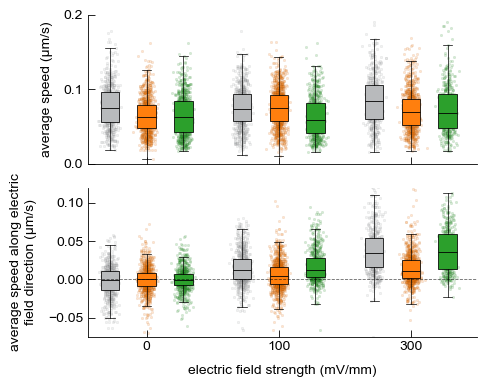

In [11]:
# Assumes df_displacement_mag and df_displacement_proj are already computed
# df_displacement_mag['mean_speed'] = df_displacement_mag['mean_speed'] / (3.0 * 60.0)
# df_displacement_proj['mean_speed'] = df_displacement_proj['mean_dx'] / (3.0 * 60.0)

displacement_records_mag = []

# Assume z column exists in df_intervals_3
for (celltype, E), group in df_intervals_3[df_intervals_3.E_V_cm.isin([0, 1, 3])].groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        dy = np.diff(d['y'].values)
        dz = np.diff(d['z'].values)
        if len(dx) == 0:
            continue
        speeds = [sqrt(dx[i]**2 + dy[i]**2 + dz[i]**2) for i in range(len(dx))]
        mean_speed = np.mean(speeds)
        displacement_records_mag.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_speed': mean_speed / (3.0 * 60.0)  # Normalize for 3-frame interval (in μm/s)
        })

df_displacement_mag = pd.DataFrame(displacement_records_mag)

displacement_records = []

for (celltype, E), group in df_intervals_3.groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        if len(dx) == 0:
            continue
        mean_dx = np.mean(dx)
        displacement_records.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_dx': mean_dx
        })

df_displacement_proj = pd.DataFrame(displacement_records)

# Normalize speed
df_displacement_proj['mean_speed'] = df_displacement_proj['mean_dx'] / (3.0 * 60.0)


######################
df_mag_plot = df_displacement_mag[df_displacement_mag.E_V_cm.isin([0, 1, 3])]
df_proj_plot = df_displacement_proj[df_displacement_proj.E_V_cm.isin([0, 1, 3])]

# Settings
E_levels = [0, 1, 3]
celltypes = [wt, ko, res]
colors = [color_dict[wt], color_dict[ko], color_dict[res]]
celltype_color_dict = dict(zip(celltypes, colors))

group_spacing = 0.9
dodge_offset = 0.25
jitter_scale = 0.025
box_width = 0.125

# Setup 2-row figure
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 4), sharex=True)

titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]
datasets = [df_mag_plot, df_proj_plot]

for row, (ax, df_plot, ylabel) in enumerate(zip(axs, datasets, titles)):
    legend_entries = {}
    
    for i, E in enumerate(E_levels):
        x_base = i * group_spacing
        for j, celltype in enumerate(celltypes):
            x_pos = x_base + (j - 1) * dodge_offset
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor=celltype_color_dict[celltype], edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0.5),
                capprops=dict(color='black', linewidth=0.5),
            )

            # Jittered scatter
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            scatter = ax.scatter(
                jittered_x, speeds,
                s=4, color=celltype_color_dict[celltype],
                alpha=0.2, edgecolor='black', linewidth=0.1,
                label=celltype if (E == 0 and celltype not in legend_entries) else None
            )
            legend_entries[celltype] = scatter

    # Formatting
    xticks = [i * group_spacing for i in range(len(E_levels))]
    xticklabels = [str(e * 100) for e in E_levels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10)
    # ax.set_yticklabels(fontsize=10)
    ax.set_xlim(-0.4, 2.25)
    ax.set_ylabel(ylabel, fontsize=10)
    
    ax.grid(False)

    if ylabel == "average speed (μm/s)":
        yticks = [0,0.1, 0.2]
        ax.set_yticks(yticks)
        ax.set_ylim(0,0.2)
    else:
        ax.hlines(y=0, xmin=-1, xmax=3 + box_width, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
        yticks = [-0.05,0.0, 0.05, 0.1, 0.15]
        ax.set_yticks(yticks)
        ax.set_ylim(-0.075,0.12)

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.6, length=5)
    ax.tick_params(axis='y', labelsize=10) 

# Shared xlabel
axs[1].set_xlabel("electric field strength (mV/mm)", fontsize=10)


# # Optional legend (from top axis)
# handles, labels = axs[0].get_legend_handles_labels()
# unique = dict(zip(labels, handles))
# fig.legend(unique.values(), unique.keys(), title='Cell Type',
           # fontsize=9, title_fontsize=10, loc='upper center', ncol=3)

plt.tight_layout()#rect=[0, 0, 1, 0.95])

# fig.savefig('../../figures/Figure2_speeds_updated_.pdf')

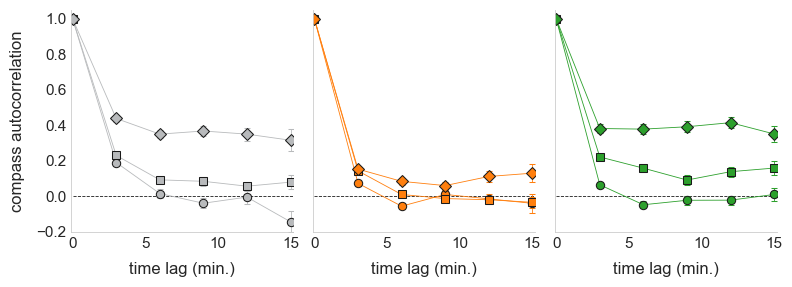

In [180]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr



marker_dict = {
    0: 'o',
    1: 's',
    3: 'D'
    # Add more if needed
}

df_intervals_3 = parse_trajectories(df_filtered_tracks, frame_step=3)

autocorr_list = []

for g, d in df_intervals_3[df_intervals_3.E_V_cm != 5].groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 3,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()

celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(8, 3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype == celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})",
            capsize=2,
            marker=marker_dict.get(e, 'o'),  # default to 'o' if unknown
            markersize=6,
            color=color_dict.get(celltype, 'gray'),  # default to gray if unknown
             markeredgecolor='k',       # black outline
            markeredgewidth=0.75       # adjust thickness as needed
        )
    # ax.set_title(celltype, fontsize=12)

for ax_ in axes:
    ax_.set_xlim(-0.1, 5*3 + 0.2)
    ax_.set_ylim(-0.2, 1.05)
    ax_.hlines(0, 0, 6*3, zorder=0, color='k', linestyle='--')
    ax_.set_xlabel('time lag (min.)')
    ax_.grid(False)

axes[0].set_ylabel('compass autocorrelation')

plt.tight_layout()
# plt.savefig('../../figures/Figure3_supp_autocorr_updated_.pdf')

   E_V_cm  statistic       p_value    metric
0       0   303353.5  2.102666e-01  autocorr
1       1   476091.0  2.676680e-03  autocorr
2       3   330962.5  4.346347e-17  autocorr


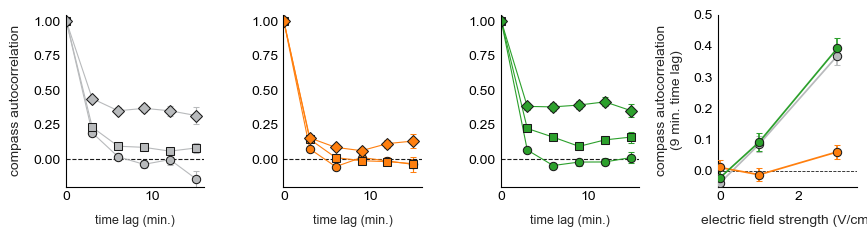

In [234]:
plt.style.use('styleNB.mplstyle')

# Choose lag of interest (in minutes)
# lag_of_interest = 9
lag_of_interest = 9
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Stats for bar plot
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

# Unique celltypes
celltypes = df_avg_autocorr.celltype.unique()
n_celltypes = len(celltypes)

# Create figure with N+1 subplots in a row
fig, axes = plt.subplots(1, n_celltypes + 1, figsize=(2.2 * (n_celltypes + 1), 2.5))

# Time series autocorrelation plots (left side)
for ax, celltype in zip(axes[:-1], celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype == celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})",
            capsize=2,
            marker=marker_dict.get(e, 'o'),
            markersize=6,
            linewidth=0.8,
            color=color_dict.get(celltype, 'gray'),
            markeredgecolor='k',
            markeredgewidth=0.75
        )
    ax.set_xlim(-0.1, 5 * 3 + 1)
    ax.set_ylim(-0.2, 1.05)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('time lag (min.)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(False)

axes[0].set_ylabel('compass autocorrelation', fontsize=10)

# Plot for fixed lag (rightmost column)
for celltype, d in df_lag_stats.groupby('celltype'):
     axes[-1].errorbar(
        d['E_V_cm'], d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1.25, marker='o', markersize=6,
        color=color_dict.get(celltype, None),
        zorder=10, capsize=2,
         markeredgecolor='k',
            markeredgewidth=0.75
    )

axes[-1].axhline(0, color='k', linestyle='--', zorder=0)
axes[-1].set_xlim(-0.05, 3.5)
axes[-1].set_ylim(-0.05, 0.5)
axes[-1].set_xlabel('electric field strength (V/cm)', fontsize=10)
axes[-1].set_ylabel('compass autocorrelation\n(9 min. time lag)', fontsize=10)
axes[-1].tick_params(labelsize=8)
axes[-1].grid(False)



for ax in axes:
    # Make all visible spines black
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)

    # Optionally hide top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set tick color and width
    ax.tick_params(axis='both', colors='black', width=0.6, length=4, labelsize=10)
    
plt.tight_layout()
# fig.savefig('../../figures/Figure2_compass_auto.pdf')

from scipy.stats import mannwhitneyu

# Define cell types
celltypes = df_avg_autocorr.celltype.unique()

# --- Cos(θ) net statistics ---
def perform_mannwhitney_cos_theta(df):
    results = []
    for ev in sorted(df['E_V_cm'].unique()):
        subset = df[df['E_V_cm'] == ev]
        group1 = subset[subset['celltype'] == celltypes[0]]['cos_theta_net'].dropna()
        group2 = subset[subset['celltype'] == celltypes[1]]['cos_theta_net'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            results.append({'E_V_cm': ev, 'statistic': stat, 'p_value': p, 'metric': 'cos_theta_net'})
    return pd.DataFrame(results)

# --- Autocorrelation statistics (only at lag = 6) ---
def perform_mannwhitney_autocorr(df):
    df_lag6 = df[df['lag'] == 9]
    results = []
    for ev in sorted(df_lag6['E_V_cm'].unique()):
        subset = df_lag6[df_lag6['E_V_cm'] == ev]
        group1 = subset[subset['celltype'] == celltypes[0]]['autocorr'].dropna()
        group2 = subset[subset['celltype'] == celltypes[1]]['autocorr'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            results.append({'E_V_cm': ev, 'statistic': stat, 'p_value': p, 'metric': 'autocorr'})
    return pd.DataFrame(results)

df_stats_autocorr = perform_mannwhitney_autocorr(df_autocorr)

# Combine
df_stats_summary = df_stats_autocorr

# Optional: print or export
print(df_stats_summary)

     metric  E_V_cm                              celltype  n_test  n_control  \
0  autocorr       0                        dHL60TMEM154KO    1026        614   
1  autocorr       0  dHL60TMEM154KO-clone1galvanin-GFP-HA     769        614   
2  autocorr       1                        dHL60TMEM154KO    1131        779   
3  autocorr       1  dHL60TMEM154KO-clone1galvanin-GFP-HA     666        779   
4  autocorr       3                        dHL60TMEM154KO     976        538   
5  autocorr       3  dHL60TMEM154KO-clone1galvanin-GFP-HA     449        538   

   median_test  median_control       p_value  
0    -0.072368        0.028684  2.218611e-02  
1    -0.068033        0.028684  5.477356e-02  
2     0.018395        0.111306  2.789722e-03  
3     0.213513        0.111306  2.365543e-02  
4     0.115199        0.471758  1.586157e-17  
5     0.490543        0.471758  1.342543e-01  


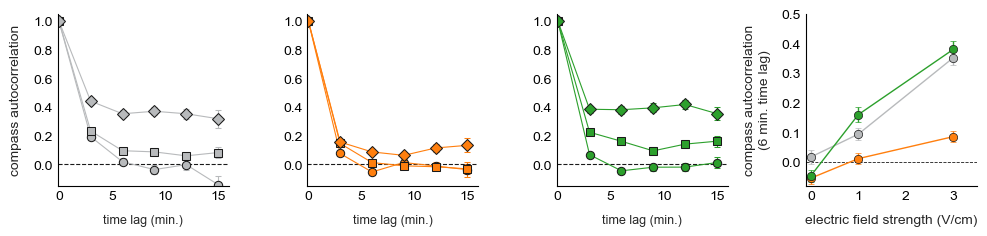

In [249]:
plt.style.use('styleNB.mplstyle')

# Choose lag of interest (in minutes)
# lag_of_interest = 9
lag_of_interest = 6
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Stats for bar plot
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

# Unique celltypes
celltypes = df_avg_autocorr.celltype.unique()
n_celltypes = len(celltypes)

# Create figure with N+1 subplots in a row
fig, axes = plt.subplots(1, n_celltypes + 1, figsize=(2.5 * (n_celltypes + 1), 2.5))

# Time series autocorrelation plots (left side)
for ax, celltype in zip(axes[:-1], celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype == celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})",
            capsize=2,
            marker=marker_dict.get(e, 'o'),
            markersize=6,
            linewidth=0.8,
            color=color_dict.get(celltype, 'gray'),
            markeredgecolor='k',
            markeredgewidth=0.75
        )
    ax.set_xlim(-0.1, 5 * 3 + 1)
    ax.set_ylim(-0.15, 1.05)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('time lag (min.)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(False)

axes[0].set_ylabel('compass autocorrelation', fontsize=10)

# Plot for fixed lag (rightmost column)
for celltype, d in df_lag_stats.groupby('celltype'):
     axes[-1].errorbar(
        d['E_V_cm'], d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1, marker='o', markersize=6,
        color=color_dict.get(celltype, None),
        zorder=10, capsize=2,
         markeredgecolor='k',
            markeredgewidth=0.5
    )

axes[-1].axhline(0, color='k', linestyle='--', zorder=0)
axes[-1].set_xlim(-0.1, 3.5)
axes[-1].set_ylim(-0.08, 0.5)
axes[-1].set_xlabel('electric field strength (V/cm)', fontsize=10)
axes[-1].set_ylabel('compass autocorrelation\n(6 min. time lag)', fontsize=10)
axes[-1].tick_params(labelsize=8)
axes[-1].grid(False)



for ax in axes:
    # Make all visible spines black
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)

    # Optionally hide top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set tick color and width
    ax.tick_params(axis='both', colors='black', width=0.6, length=4, labelsize=10)
    
plt.tight_layout()
# fig.savefig('../../figures/Figure2_compass_auto.pdf')
plt.savefig('../../figures/Figure2_compassautocorr_updated_.pdf')

from scipy.stats import mannwhitneyu

# Define cell types
celltypes = df_avg_autocorr.celltype.unique()
# Explicitly define groups
test_celltypes = [
         'dHL60TMEM154KO',
       'dHL60TMEM154KO-clone1galvanin-GFP-HA'
]
control_celltype = 'dHL60KW'


# --- Autocorrelation statistics (only at one time lag) ---
def perform_mannwhitney_autocorr(df):
    df_lag9 = df[df['lag'] == 6]  # assuming lag 9 is desired
    results = []
    for ev in sorted(df_lag9['E_V_cm'].unique()):
        for test_ct in test_celltypes:
            group1 = df_lag9[(df_lag9['E_V_cm'] == ev) & (df_lag9['celltype'] == test_ct)]['autocorr'].dropna()
            group2 = df_lag9[(df_lag9['E_V_cm'] == ev) & (df_lag9['celltype'] == control_celltype)]['autocorr'].dropna()
            if len(group1) > 0 and len(group2) > 0:
                stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
                results.append({
                    'E_V_cm': ev,
                    'celltype': test_ct,
                    'control': control_celltype,
                    'statistic': stat,
                    'p_value': p,
                    'metric': 'autocorr',
                    'n_test': len(group1),
                    'n_control': len(group2),
                    'median_test': group1.median(),
                    'median_control': group2.median()
                })
    return pd.DataFrame(results)

df_stats_autocorr = perform_mannwhitney_autocorr(df_autocorr)

# Combine
df_stats_summary = df_stats_autocorr

# Optional: print or export
# print(df_stats_summary)
print(df_stats_summary[['metric', 'E_V_cm', 'celltype', 'n_test', 'n_control', 'median_test', 'median_control', 'p_value']])




In [21]:
2.789722e-03

0.002789722

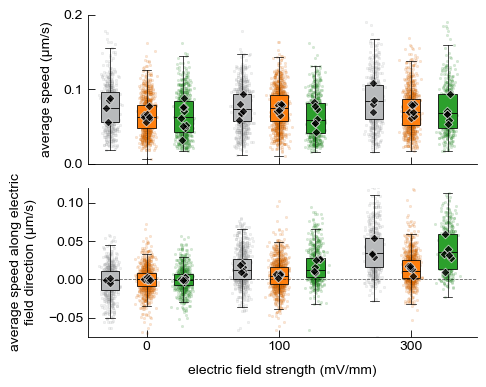

In [12]:
# Calculate average values per replicate for magnitude and projection
avg_mag_replicate = (
    df_mag_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

avg_proj_replicate = (
    df_proj_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

# Settings
E_levels = [0, 1, 3]
celltypes = [wt, ko, res]
colors = [color_dict[wt], color_dict[ko], color_dict[res]]
celltype_color_dict = dict(zip(celltypes, colors))

group_spacing = 0.9
dodge_offset = 0.25
jitter_scale = 0.025
box_width = 0.125

# Setup 2-row figure
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 4), sharex=True)

titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]
datasets = [df_mag_plot, df_proj_plot]
avg_datasets = [avg_mag_replicate, avg_proj_replicate]

for row, (ax, df_plot, avg_plot, ylabel) in enumerate(zip(axs, datasets, avg_datasets, titles)):
    legend_entries = {}
    
    for i, E in enumerate(E_levels):
        x_base = i * group_spacing
        for j, celltype in enumerate(celltypes):
            x_pos = x_base + (j - 1) * dodge_offset
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor=celltype_color_dict[celltype], edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0.5),
                capprops=dict(color='black', linewidth=0.5),
            )

            # Jittered scatter (individual points)
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            scatter = ax.scatter(
                jittered_x, speeds,
                s=4, color=celltype_color_dict[celltype],
                alpha=0.2, edgecolor='black', linewidth=0.1,
                label=celltype if (E == 0 and celltype not in legend_entries) else None
            )
            legend_entries[celltype] = scatter

            # Scatter average replicate points
            avg_subset = avg_plot[(avg_plot.celltype == celltype) & (avg_plot.E_V_cm == E)]
            if not avg_subset.empty:
                avg_x = np.random.normal(loc=x_pos, scale=jitter_scale/2, size=len(avg_subset))
                ax.scatter(
                    avg_x, avg_subset['mean_speed'],
                    s=20, color='black', alpha=0.8,
                    marker='D', linewidth=0.5, edgecolor='white',
                    zorder=5
                )

    # Formatting
    xticks = [i * group_spacing for i in range(len(E_levels))]
    xticklabels = [str(e * 100) for e in E_levels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10)
    ax.set_xlim(-0.4, 2.25)
    ax.set_ylabel(ylabel, fontsize=10)
    
    ax.grid(False)

    if ylabel == "average speed (μm/s)":
        yticks = [0,0.1, 0.2]
        ax.set_yticks(yticks)
        ax.set_ylim(0,0.2)
    else:
        ax.hlines(y=0, xmin=-1, xmax=3 + box_width, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
        yticks = [-0.05,0.0, 0.05, 0.1, 0.15]
        ax.set_yticks(yticks)
        ax.set_ylim(-0.075,0.12)

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.6, length=5)
    ax.tick_params(axis='y', labelsize=10)

# Shared xlabel
axs[1].set_xlabel("electric field strength (mV/mm)", fontsize=10)

plt.tight_layout()
# fig.savefig('../../figures/Figure2_speeds_updated_.pdf')


Magnitude comparisons (KO vs WT): {0: {'U_stat': 8.0, 'p_value': 0.3151515151515151, 'n_a': 7, 'n_b': 4}, 1: {'U_stat': 29.0, 'p_value': 0.5727605727605728, 'n_a': 8, 'n_b': 6}, 3: {'U_stat': 7.0, 'p_value': 0.2303030303030303, 'n_a': 7, 'n_b': 4}}

Magnitude comparisons (Rescue vs WT): {0: {'U_stat': 10.0, 'p_value': 0.2601398601398601, 'n_a': 9, 'n_b': 4}, 1: {'U_stat': 14.0, 'p_value': 0.36596736596736595, 'n_a': 7, 'n_b': 6}, 3: {'U_stat': 4.0, 'p_value': 0.11428571428571428, 'n_a': 6, 'n_b': 4}}

Projection comparisons (KO vs WT): {0: {'U_stat': 20.0, 'p_value': 0.3151515151515151, 'n_a': 7, 'n_b': 4}, 1: {'U_stat': 1.0, 'p_value': 0.001332001332001332, 'n_a': 8, 'n_b': 6}, 3: {'U_stat': 0.0, 'p_value': 0.006060606060606061, 'n_a': 7, 'n_b': 4}}

Projection comparisons (Rescue vs WT): {0: {'U_stat': 25.0, 'p_value': 0.3300699300699301, 'n_a': 9, 'n_b': 4}, 1: {'U_stat': 27.0, 'p_value': 0.4452214452214452, 'n_a': 7, 'n_b': 6}, 3: {'U_stat': 9.0, 'p_value': 0.6095238095238095, 'n_

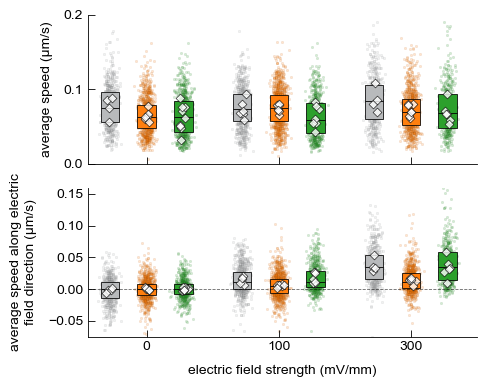

In [19]:
# Calculate average values per replicate for magnitude and projection
avg_mag_replicate = (
    df_mag_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

avg_proj_replicate = (
    df_proj_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

# Perform statistical tests (Mann-Whitney U) comparing averages of each replicate
from scipy.stats import mannwhitneyu

def run_stats(avg_df, E_levels, cell_a, cell_b):
    results = {}
    for E in E_levels:
        subset_a = avg_df[(avg_df.celltype == cell_a) & (avg_df.E_V_cm == E)]['mean_speed']
        subset_b = avg_df[(avg_df.celltype == cell_b) & (avg_df.E_V_cm == E)]['mean_speed']

        if len(subset_a) > 0 and len(subset_b) > 0:
            stat, p = mannwhitneyu(subset_a, subset_b, alternative='two-sided')
            results[E] = {'U_stat': stat, 'p_value': p, 'n_a': len(subset_a), 'n_b': len(subset_b)}
    return results

# Example cell types
cell_wt = 'dHL60KW'
cell_ko = 'dHL60TMEM154KO'
cell_rescue = 'dHL60TMEM154KO-clone1galvanin-GFP-HA'

print("\nMagnitude comparisons (KO vs WT):", run_stats(avg_mag_replicate, E_levels, cell_ko, cell_wt))
print("\nMagnitude comparisons (Rescue vs WT):", run_stats(avg_mag_replicate, E_levels, cell_rescue, cell_wt))

print("\nProjection comparisons (KO vs WT):", run_stats(avg_proj_replicate, E_levels, cell_ko, cell_wt))
print("\nProjection comparisons (Rescue vs WT):", run_stats(avg_proj_replicate, E_levels, cell_rescue, cell_wt))

# Settings
E_levels = [0, 1, 3]
celltypes = [wt, ko, res]
colors = [color_dict[wt], color_dict[ko], color_dict[res]]
celltype_color_dict = dict(zip(celltypes, colors))

group_spacing = 0.9
dodge_offset = 0.25
jitter_scale = 0.025
box_width = 0.125

# Setup 2-row figure
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 4), sharex=True)

titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]
datasets = [df_mag_plot, df_proj_plot]
avg_datasets = [avg_mag_replicate, avg_proj_replicate]

for row, (ax, df_plot, avg_plot, ylabel) in enumerate(zip(axs, datasets, avg_datasets, titles)):
    legend_entries = {}
    
    for i, E in enumerate(E_levels):
        x_base = i * group_spacing
        for j, celltype in enumerate(celltypes):
            x_pos = x_base + (j - 1) * dodge_offset
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor=celltype_color_dict[celltype], edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0),
                capprops=dict(color='black', linewidth=0),
            )

            # Jittered scatter (individual points)
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            scatter = ax.scatter(
                jittered_x, speeds,
                s=4, color=celltype_color_dict[celltype],
                alpha=0.2, edgecolor='black', linewidth=0.1,
                label=celltype if (E == 0 and celltype not in legend_entries) else None
            )
            legend_entries[celltype] = scatter

            # Scatter average replicate points
            avg_subset = avg_plot[(avg_plot.celltype == celltype) & (avg_plot.E_V_cm == E)]
            if not avg_subset.empty:
                avg_x = np.random.normal(loc=x_pos, scale=jitter_scale/2, size=len(avg_subset))
                ax.scatter(
                    avg_x, avg_subset['mean_speed'],
                    s=20, alpha=0.8,
                    marker='D', linewidth=0.5, edgecolor='black', color='white',#edgecolor='white', color='black',
                    zorder=5
                )

    # Formatting
    xticks = [i * group_spacing for i in range(len(E_levels))]
    xticklabels = [str(e * 100) for e in E_levels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10)
    ax.set_xlim(-0.4, 2.25)
    ax.set_ylabel(ylabel, fontsize=10)
    
    ax.grid(False)

    if ylabel == "average speed (μm/s)":
        yticks = [0,0.1, 0.2]
        ax.set_yticks(yticks)
        ax.set_ylim(0,0.2)
    else:
        ax.hlines(y=0, xmin=-1, xmax=3 + box_width, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
        yticks = [-0.05,0.0, 0.05, 0.1, 0.15]
        ax.set_yticks(yticks)
        ax.set_ylim(-0.075,0.16)

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.6, length=5)
    ax.tick_params(axis='y', labelsize=10)

# Shared xlabel
axs[1].set_xlabel("electric field strength (mV/mm)", fontsize=10)

plt.tight_layout()
fig.savefig('../../figures/Figure2_speeds_updated_2.pdf')